## ****MODELING (PEMODELAN)****

---

Tahap ini memakai output Data Preparation (train_fit.csv, train_val.csv, test_clean.csv) apa adanya, tanpa mengubah fitur. Fokusnya memilih algoritma, menguji hipotesis dari Data Understanding secara kuantitatif, dan mengejar RMSE serendah mungkin.

### ****PEMUATAN DATA DAN BASELINE****

Memuat train_fit dan train_val hasil Data Preparation, lalu membangun tiga baseline sederhana sebagai acuan RMSE minimum yang harus dilampaui model sesungguhnya: prediksi rata-rata global, station_target_mean, dan loc_hour_target_mean. Baseline ini menjawab kriteria Measurable pada Business Understanding.

In [1]:
import pandas as pd
import numpy as np

In [2]:
CLEAN_DIR = "../Dataset/Clean"
TARGET_COL = "utilization_rate"
ID_COLS = ["id", "station_id", "timestamp"]

train_fit = pd.read_csv(f"{CLEAN_DIR}/train_fit.csv", parse_dates=["timestamp"])
train_val = pd.read_csv(f"{CLEAN_DIR}/train_val.csv", parse_dates=["timestamp"])

FEATURE_COLS = [col for col in train_fit.columns if col not in ID_COLS + [TARGET_COL]]

X_fit, y_fit = train_fit[FEATURE_COLS], train_fit[TARGET_COL]
X_val, y_val = train_val[FEATURE_COLS], train_val[TARGET_COL]

print(f"train_fit : {X_fit.shape} | train_val : {X_val.shape}")
print(f"Jumlah fitur: {len(FEATURE_COLS)}")


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error, metrik evaluasi resmi kompetisi."""
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

train_fit : (885600, 26) | train_val : (168600, 26)
Jumlah fitur: 26


In [3]:
results = {}

baseline_global_pred = np.full(len(y_val), y_fit.mean())
results["Baseline: rata-rata global"] = rmse(y_val, baseline_global_pred)

baseline_station_pred = X_val["station_target_mean"]
results["Baseline: station_target_mean"] = rmse(y_val, baseline_station_pred)

baseline_loc_hour_pred = X_val["loc_hour_target_mean"]
results["Baseline: loc_hour_target_mean"] = rmse(y_val, baseline_loc_hour_pred)

for name, score in results.items():
    print(f"{name:35s}: RMSE = {score:.4f}")

Baseline: rata-rata global         : RMSE = 0.3190
Baseline: station_target_mean      : RMSE = 0.3026
Baseline: loc_hour_target_mean     : RMSE = 0.1429


### ****MODEL REFERENSI: LINEAR REGRESSION****

Melatih Linear Regression sebagai referensi.

kolom kategorik di sini memakai label encoding (kode integer tanpa urutan bermakna), yang cocok untuk model berbasis pohon tapi kurang tepat untuk model linear, karena model linear akan menganggap jarak antar kode punya arti. Karena itu, skor Linear Regression di sini hanya jadi titik referensi kasar, bukan kandidat model final.

In [4]:
from sklearn.linear_model import LinearRegression
import time

start = time.time()
model_lr = LinearRegression()
model_lr.fit(X_fit, y_fit)
pred_lr = model_lr.predict(X_val)
elapsed = time.time() - start

results["Linear Regression"] = rmse(y_val, pred_lr)
print(f"Linear Regression : RMSE = {results['Linear Regression']:.4f} | waktu latih = {elapsed:.1f}s")

Linear Regression : RMSE = 0.1356 | waktu latih = 1.3s


### ****MODEL UTAMA: RANDOM FOREST DAN LIGHTGBM****

Melatih dua model berbasis pohon yang menangani label encoding, interaksi antarfitur, dan hubungan nonlinear secara alami, sesuai temuan Data Understanding. Parameter dibatasi (n_estimators, max_depth) untuk menjaga waktu latih tetap wajar pada 885.600 baris, sambil tetap menjadi titik awal yang representatif sebelum tuning.

In [5]:
from sklearn.ensemble import RandomForestRegressor

start = time.time()
model_rf = RandomForestRegressor(
    n_estimators=200, max_depth=16, min_samples_leaf=20,
    n_jobs=-1, random_state=42,
)
model_rf.fit(X_fit, y_fit)
pred_rf = model_rf.predict(X_val)
elapsed = time.time() - start

results["Random Forest"] = rmse(y_val, pred_rf)
print(f"Random Forest : RMSE = {results['Random Forest']:.4f} | waktu latih = {elapsed:.1f}s")

Random Forest : RMSE = 0.1284 | waktu latih = 494.7s


In [6]:
from lightgbm import LGBMRegressor

start = time.time()
model_lgb = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    random_state=42, n_jobs=-1, verbosity=-1,
)
model_lgb.fit(X_fit, y_fit)
pred_lgb = model_lgb.predict(X_val)
elapsed = time.time() - start

results["LightGBM"] = rmse(y_val, pred_lgb)
print(f"LightGBM : RMSE = {results['LightGBM']:.4f} | waktu latih = {elapsed:.1f}s")

LightGBM : RMSE = 0.1125 | waktu latih = 18.6s


In [7]:
comparison = pd.Series(results).sort_values().rename("RMSE").to_frame()
comparison["selisih_vs_baseline_terbaik"] = comparison["RMSE"] - results["Baseline: loc_hour_target_mean"]
display(comparison.round(4))

,RMSE,selisih_vs_baseline_terbaik
LightGBM,0.1125,-0.0304
Random Forest,0.1284,-0.0145
Linear Regression,0.1356,-0.0073
Baseline: loc_hour_target_mean,0.1429,0.0000
Baseline: station_target_mean,0.3026,0.1597
Baseline: rata-rata global,0.3190,0.1761


### ****TEMUAN PERBANDINGAN MODEL****

LightGBM memberikan RMSE terbaik (0,1125), mengungguli Random Forest (0,1284) dengan waktu latih jauh lebih singkat, dan mengungguli baseline loc_hour_target_mean sebesar 0,0304. Random Forest tidak proporsional: waktu latihnya 33 kali lebih lama untuk hasil yang lebih buruk, sehingga tidak dilanjutkan ke tahap tuning.

Linear Regression mengungguli baseline meski encoding kategoriknya secara teoretis kurang cocok untuknya, mengindikasikan sebagian besar sinyal berasal dari fitur numerik dan target encoding. LightGBM dipilih sebagai kandidat utama.

### ****FEATURE IMPORTANCE LIGHTGBM****

Melihat fitur mana yang paling menentukan prediksi model, untuk kebutuhan interpretasi pada tahap Evaluation (faktor paling berpengaruh dan saran strategis sesuai tuntutan panitia).

,importance
loc_hour_target_mean,10491
station_target_mean,7608
day_of_week,2109
latitude,1903
hour,1810
longitude,1368
temperature_f,1168
location_type_code,971
precipitation_mm,522
hour_cos,477


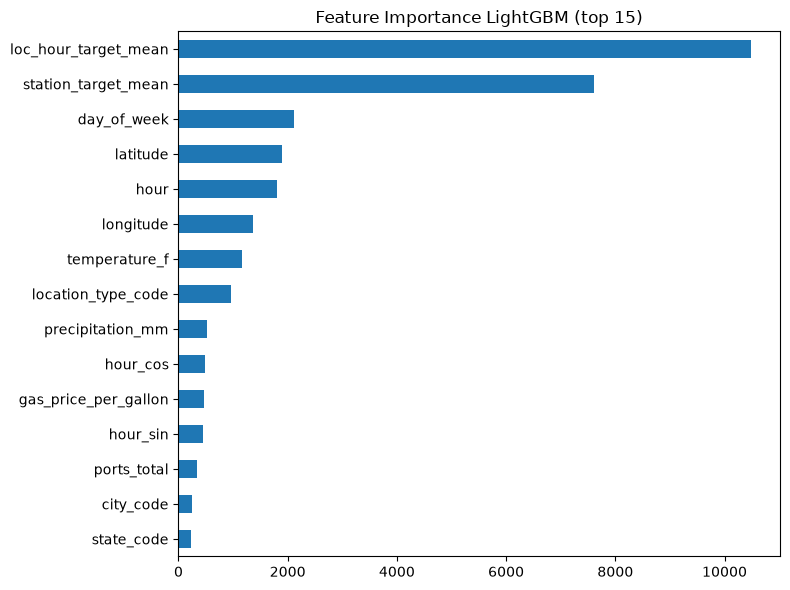

In [8]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(model_lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

display(feature_importance.head(15).to_frame("importance"))

feature_importance.head(15).sort_values().plot.barh(figsize=(8, 6), title="Feature Importance LightGBM (top 15)")
plt.tight_layout()
plt.show()

#### ****Temuan Feature Importance****

loc_hour_target_mean (10.491) dan station_target_mean (7.608) mendominasi, jauh melampaui gabungan 13 fitur lainnya. Ini konsisten dengan RMSE baseline loc_hour_target_mean sendirian (0,1429) yang sudah mendekati skor model penuh.

day_of_week, latitude, longitude, dan hour berada di tingkat menengah, menambahkan sinyal spasial dan temporal di luar yang sudah ditangkap target encoding. city_code dan state_code justru sangat rendah (254 dan 225) meski Data Understanding menunjukkan variasi target antarkota cukup lebar (sekitar 0,30 sampai 0,54). Ini mengindikasikan city dan state redundan terhadap latitude, longitude, dan station_target_mean yang sudah lebih granular, bukan berarti lokasi tidak penting.

gas_price_per_gallon tergolong rendah (475) meski korelasi Pearson-nya 0,166 pada Data Understanding, kemungkinan karena model sudah menangkap efek musiman lewat temperature_f dan fitur bulan secara implisit (month tidak masuk top 15, kemungkinan karena tumpang tindih dengan temperature_f yang berkorelasi -0,69 dengannya).

### ****ANALISIS ERROR PER SEGMEN****

Memeriksa RMSE per location_type dan per weather_condition, khususnya freezing yang sama sekali tidak ada di train_fit, untuk menilai seberapa baik model bergeneralisasi ke kondisi tak terlihat. Juga memeriksa proporsi prediksi yang keluar dari rentang 0,02 sampai 0,98 sebelum dan sesudah clipping.

In [10]:
df_val_eval = train_val[["location_type_code", "weather_condition_code"]].copy()
df_val_eval["y_true"] = y_val.values
df_val_eval["y_pred"] = pred_lgb

def rmse_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return df.groupby(group_col).apply(
        lambda g: pd.Series({"RMSE": rmse(g["y_true"], g["y_pred"]), "n_baris": len(g)}),
        include_groups=False,
    ).sort_values("RMSE", ascending=False)

print("RMSE per location_type_code (mapping: Airport=0, Highway Corridor=1, Hotel/Hospitality=2, "
      "Residential=3, Shopping Center=4, Suburban=5, Urban Center=6, Workplace=7):")
display(rmse_by_group(df_val_eval, "location_type_code").round(4))

print("RMSE per weather_condition_code (-1 = freezing, kondisi tak terlihat saat training):")
display(rmse_by_group(df_val_eval, "weather_condition_code").round(4))

RMSE per location_type_code (mapping: Airport=0, Highway Corridor=1, Hotel/Hospitality=2, Residential=3, Shopping Center=4, Suburban=5, Urban Center=6, Workplace=7):


,RMSE,n_baris
location_type_code,,
6,0.1260,23604.0
4,0.1219,21356.0
1,0.1205,21356.0
0,0.1178,25852.0
5,0.1176,22480.0
2,0.1174,19108.0
7,0.0758,19108.0
3,0.0758,15736.0


RMSE per weather_condition_code (-1 = freezing, kondisi tak terlihat saat training):


,RMSE,n_baris
weather_condition_code,,
-1,0.1505,23953.0
4,0.1094,22306.0
0,0.1047,59210.0
1,0.1044,29896.0
5,0.1036,29710.0
3,0.0947,3525.0


In [11]:
n_below = (pred_lgb < 0.02).sum()
n_above = (pred_lgb > 0.98).sum()
print(f"Prediksi di luar rentang: {n_below:,} di bawah 0,02 | {n_above:,} di atas 0,98 (dari {len(pred_lgb):,} baris)")

pred_lgb_clipped = np.clip(pred_lgb, 0.02, 0.98)
rmse_before = rmse(y_val, pred_lgb)
rmse_after = rmse(y_val, pred_lgb_clipped)
print(f"RMSE sebelum clip : {rmse_before:.4f}")
print(f"RMSE sesudah clip : {rmse_after:.4f}")

Prediksi di luar rentang: 2,859 di bawah 0,02 | 0 di atas 0,98 (dari 168,600 baris)
RMSE sebelum clip : 0.1125
RMSE sesudah clip : 0.1125


#### ****Temuan Error per Segmen dan Dampak Clipping****

**Per location_type**
RMSE tertinggi pada Urban Center (0,1260), Shopping Center (0,1219), dan Highway Corridor (0,1205), yaitu tipe lokasi dengan pola dua puncak (bimodal) pada Data Understanding. RMSE terendah pada Workplace dan Residential (masing-masing 0,0758), tipe lokasi dengan pola satu puncak yang lebih sederhana. Model lebih sulit memprediksi lokasi dengan pola jam kompleks.

**Per weather_condition**
RMSE tertinggi pada freezing (0,1505, kode -1), kondisi yang sama sekali tidak dipelajari saat training, mengonfirmasi kekhawatiran sebelumnya soal generalisasi. Menariknya, heavy_rain justru RMSE terendah (0,0947) meski termasuk kejadian ekstrem, yang disini kemungkinan karena precipitation_mm memberi sinyal kuat dan konsisten untuk kondisi ini. Sejalan dengan temuan uplift -0,061 pada Data Understanding. clear, cloudy, dan partly_cloudy berada di tengah (sekitar 0,104 sampai 0,105).

**Clipping**
2.859 prediksi (1,7%) berada di bawah 0,02 dan tidak ada di atas 0,98. RMSE sebelum dan sesudah clip sama-sama 0,1125 pada 4 desimal, karena porsi yang di-clip kecil dan sebagian besar sudah sangat dekat dengan 0,02. Clipping tetap dipertahankan pada prediksi final karena tidak merugikan dan menjamin validitas rentang output.

### ****TUNING RINGAN LIGHTGBM****

Mencoba beberapa kombinasi num_leaves dan learning_rate dengan early stopping pada train_val, untuk mendapatkan model yang lebih baik tanpa pencarian menyeluruh yang memakan waktu. early_stopping menghentikan penambahan pohon begitu RMSE validasi berhenti membaik, sehingga n_estimators besar (2000) aman dipakai sebagai batas atas.

In [12]:
from lightgbm import LGBMRegressor, early_stopping

param_grid = [
    {"num_leaves": 31, "learning_rate": 0.05},
    {"num_leaves": 63, "learning_rate": 0.05},
    {"num_leaves": 127, "learning_rate": 0.05},
    {"num_leaves": 63, "learning_rate": 0.1},
    {"num_leaves": 63, "learning_rate": 0.03},
]

tuning_results = []
for params in param_grid:
    start = time.time()
    model = LGBMRegressor(n_estimators=2000, random_state=42, n_jobs=-1, verbosity=-1, **params)
    model.fit(
        X_fit, y_fit,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
    )
    pred = model.predict(X_val)
    score = rmse(y_val, pred)
    elapsed = time.time() - start
    tuning_results.append({**params, "best_iteration": model.best_iteration_, "RMSE": round(score, 4), "waktu_s": round(elapsed, 1)})
    print(f"{params} -> RMSE={score:.4f} | best_iteration={model.best_iteration_} | waktu={elapsed:.1f}s")

df_tuning = pd.DataFrame(tuning_results).sort_values("RMSE")
display(df_tuning)

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


{'num_leaves': 31, 'learning_rate': 0.05} -> RMSE=0.1013 | best_iteration=123 | waktu=6.6s


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


{'num_leaves': 63, 'learning_rate': 0.05} -> RMSE=0.1025 | best_iteration=96 | waktu=5.9s


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


{'num_leaves': 63, 'learning_rate': 0.1} -> RMSE=0.1025 | best_iteration=47 | waktu=3.6s


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


{'num_leaves': 63, 'learning_rate': 0.03} -> RMSE=0.1025 | best_iteration=154 | waktu=8.7s


,num_leaves,learning_rate,best_iteration,RMSE,waktu_s
0,31,0.05,123,0.1013,6.6
1,63,0.05,96,0.1025,5.9
3,63,0.10,47,0.1025,3.6
4,63,0.03,154,0.1025,8.7
2,127,0.05,91,0.1058,6.8


#### Temuan: Hasil Tuning Ringan

Konfigurasi terbaik adalah num_leaves=31, learning_rate=0,05, dengan RMSE 0,1013 pada best_iteration=123 — mengungguli LightGBM default (0,1125) sebesar 0,0112. Tiga dari lima kombinasi berhenti pada iterasi yang jauh lebih awal (47-154) berkat early stopping, jauh di bawah batas atas n_estimators=2000, menandakan model sudah menemukan titik optimalnya cepat. Konfigurasi ini dipakai untuk melatih model final.

### ****FINALISASI: MODEL PENUH DAN PREDIKSI TEST****

Menggabungkan train_fit dan train_val menjadi satu set latih penuh (Juli sampai November), menghitung ulang station_target_mean dan loc_hour_target_mean secara leave-one-out atas gabungan ini agar memanfaatkan seluruh data yang tersedia, lalu memetakan rata-rata penuh (bukan LOO) ke test_clean. weather_condition_code tidak dihitung ulang, karena kode -1 untuk freezing sudah konsisten antara train_val dan test, sehingga model tetap bisa mempelajari pola freezing dari baris November di set latih penuh. Model final dilatih dengan parameter terbaik hasil tuning, tanpa early stopping (karena tidak ada set validasi terpisah lagi), memakai jumlah pohon (n_estimators) sama dengan best_iteration hasil tuning.

In [13]:
def compute_loo_target_mean(df: pd.DataFrame, group_cols: list, target_col: str) -> pd.Series:
    """Rata-rata target per grup tanpa menyertakan baris itu sendiri (leave-one-out)."""
    group_sum = df.groupby(group_cols)[target_col].transform("sum")
    group_count = df.groupby(group_cols)[target_col].transform("count")
    return (group_sum - df[target_col]) / (group_count - 1)

def apply_target_mean_mapping(df: pd.DataFrame, group_mean: pd.Series, group_cols: list,
                              global_mean: float, feature_name: str) -> pd.DataFrame:
    """Terapkan rata-rata target hasil fit ke df lain lewat merge, dengan fallback rata-rata global."""
    mapping_df = group_mean.rename(feature_name).reset_index()
    df = df.merge(mapping_df, on=group_cols, how="left")
    df[feature_name] = df[feature_name].fillna(global_mean)
    return df

train_full = pd.concat([train_fit, train_val], ignore_index=True).drop(
    columns=["station_target_mean", "loc_hour_target_mean"]
)
GLOBAL_MEAN_FULL = train_full[TARGET_COL].mean()

train_full["station_target_mean"] = compute_loo_target_mean(train_full, ["station_id"], TARGET_COL)
station_mean_mapping_full = train_full.groupby("station_id")[TARGET_COL].mean()

train_full["loc_hour_target_mean"] = compute_loo_target_mean(train_full, ["location_type_code", "hour"], TARGET_COL)
loc_hour_mean_mapping_full = train_full.groupby(["location_type_code", "hour"])[TARGET_COL].mean()

test_clean = pd.read_csv(f"{CLEAN_DIR}/test_clean.csv", parse_dates=["timestamp"]).drop(
    columns=["station_target_mean", "loc_hour_target_mean"]
)
test_clean = apply_target_mean_mapping(test_clean, station_mean_mapping_full, ["station_id"], GLOBAL_MEAN_FULL, "station_target_mean")
test_clean = apply_target_mean_mapping(test_clean, loc_hour_mean_mapping_full, ["location_type_code", "hour"], GLOBAL_MEAN_FULL, "loc_hour_target_mean")

print(f"train_full : {train_full.shape}")
print(f"test_clean : {test_clean.shape}")
print(f"NaN pada test setelah remap -> station: {test_clean['station_target_mean'].isna().sum()}, "
      f"loc_hour: {test_clean['loc_hour_target_mean'].isna().sum()}")

train_full : (1054200, 30)
test_clean : (263550, 29)
NaN pada test setelah remap -> station: 0, loc_hour: 0


In [14]:
BEST_PARAMS = {"num_leaves": 31, "learning_rate": 0.05}
BEST_N_ESTIMATORS = 123  # best_iteration hasil tuning

X_full, y_full = train_full[FEATURE_COLS], train_full[TARGET_COL]
X_test = test_clean[FEATURE_COLS]

model_final = LGBMRegressor(n_estimators=BEST_N_ESTIMATORS, random_state=42, n_jobs=-1, verbosity=-1, **BEST_PARAMS)
model_final.fit(X_full, y_full)
model_final.booster_.save_model(f"{CLEAN_DIR}/model_lightgbm_final.txt")

pred_test = model_final.predict(X_test)
pred_test_clipped = np.clip(pred_test, 0.02, 0.98)
n_clipped = ((pred_test < 0.02) | (pred_test > 0.98)).sum()

print(f"Prediksi test: min={pred_test_clipped.min():.4f}, max={pred_test_clipped.max():.4f}, mean={pred_test_clipped.mean():.4f}")
print(f"Baris di-clip: {n_clipped:,} dari {len(pred_test):,}")

Prediksi test: min=0.0200, max=0.9800, mean=0.4466
Baris di-clip: 1,261 dari 263,550


In [15]:
SUBMISSION_DIR = "../Dataset/Submission"

submission = pd.DataFrame({"id": test_clean["id"], TARGET_COL: pred_test_clipped})
submission.to_csv(f"{SUBMISSION_DIR}/Daigaku Coffee Time_Submission.csv", index=False)

print(f"Tersimpan: {SUBMISSION_DIR}/Daigaku Coffee Time_Submission.csv")
print(f"Dimensi   : {submission.shape}")
display(submission.head())

Tersimpan: ../Dataset/Submission/Daigaku Coffee Time_Submission.csv
Dimensi   : (263550, 2)


,id,utilization_rate
0,TST_0U33RJ,0.900309
1,TST_V0LFA4,0.752788
2,TST_J07LFI,0.635813
3,TST_K4KBB3,0.925302
4,TST_OB0S2M,0.573196


Jumlah baris cocok dengan test : True
id unik                        : True
Nilai kosong                   : 0
Rentang prediksi               : 0.0200 s/d 0.9800


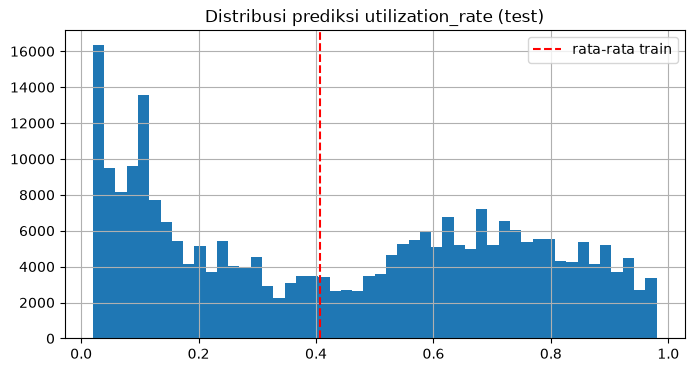

In [16]:
print(f"Jumlah baris cocok dengan test : {len(submission) == len(test_clean)}")
print(f"id unik                        : {submission['id'].nunique() == len(submission)}")
print(f"Nilai kosong                   : {submission.isna().sum().sum()}")
print(f"Rentang prediksi               : {submission[TARGET_COL].min():.4f} s/d {submission[TARGET_COL].max():.4f}")

submission[TARGET_COL].hist(bins=50, figsize=(8, 4))
plt.title("Distribusi prediksi utilization_rate (test)")
plt.axvline(train_full[TARGET_COL].mean(), color="red", linestyle="--", label="rata-rata train")
plt.legend()
plt.show()

**Hasil submission v1 ke Kaggle:**

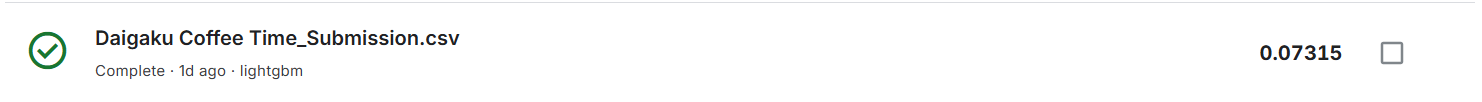

#### Temuan: Submission V1

Skor leaderboard Kaggle: **RMSE 0,07315**. Angka ini justru lebih baik daripada RMSE validasi saat tuning (0,1013), karena model final dilatih dari seluruh data Juli - November, sementara skor tuning hanya berdasarkan model yang dilatih dari Juli–Oktober. Submission ini kami jadikan acuan awal, sebelum masuk ke rangkaian eksperimen lanjutan untuk menurunkan RMSE lebih jauh.

---

### ****VALIDASI SILANG BERBASIS WAKTU (ROLLING TIME-SERIES CV)****

Membangun 4 fold dengan expanding window: fold 1 latih Juli, validasi Agustus; fold 2 latih Juli-Agustus, validasi September; dan seterusnya sampai fold 4 latih Juli-Oktober, validasi November. Setiap fold menghitung ulang target encoding (leave-one-out pada fold-train, dipetakan ke fold-val) secara independen, sehingga tidak ada informasi yang bocor antarfold. Pendekatan ini lebih andal daripada satu partisi November saja, karena rata-rata dan sebaran RMSE antarfold menunjukkan seberapa stabil performa model di berbagai rezim bulan, sekaligus menjadi acuan yang adil untuk menguji fitur baru.

In [17]:
from lightgbm import LGBMRegressor, early_stopping


def build_fold_features(df: pd.DataFrame, train_mask: pd.Series, val_mask: pd.Series,
                        encoding_specs: list, target_col: str = TARGET_COL) -> tuple:
    drop_cols = [feature_name for _, feature_name in encoding_specs]
    df_tr = df.loc[train_mask].drop(columns=drop_cols, errors="ignore").copy()
    df_va = df.loc[val_mask].drop(columns=drop_cols, errors="ignore").copy()
    global_mean = df_tr[target_col].mean()

    for group_cols, feature_name in encoding_specs:
        df_tr[feature_name] = compute_loo_target_mean(df_tr, group_cols, target_col)
        mapping = df_tr.groupby(group_cols)[target_col].mean()
        df_va = apply_target_mean_mapping(df_va, mapping, group_cols, global_mean, feature_name)

    return df_tr, df_va

def run_cv(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
          params: dict, max_estimators: int = 1000, stopping_rounds: int = 50) -> tuple:
    """Jalankan CV berbasis waktu, kembalikan skor RMSE dan best_iteration tiap fold."""
    fold_scores, fold_best_iters = [], []
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features(df, train_mask, val_mask, encoding_specs)

        model = LGBMRegressor(n_estimators=max_estimators, random_state=42, n_jobs=-1, verbosity=-1, **params)
        model.fit(
            df_tr[feature_cols], df_tr[TARGET_COL],
            eval_set=[(df_va[feature_cols], df_va[TARGET_COL])],
            eval_metric="rmse",
            callbacks=[early_stopping(stopping_rounds=stopping_rounds, verbose=False)],
        )
        pred = model.predict(df_va[feature_cols])
        score = rmse(df_va[TARGET_COL].values, pred)
        fold_scores.append(score)
        fold_best_iters.append(model.best_iteration_)
        print(f"Fold {i} ({fold['train_end']} -> {fold['val_end']}): "
              f"n_train={len(df_tr):,}, n_val={len(df_va):,}, RMSE={score:.4f}, best_iter={model.best_iteration_}")

    print(f"\nRata-rata RMSE: {np.mean(fold_scores):.4f} (std {np.std(fold_scores):.4f})")
    return fold_scores, fold_best_iters

FOLD_DEFS = [
    {"train_end": "2025-08-01", "val_end": "2025-09-01"},
    {"train_end": "2025-09-01", "val_end": "2025-10-01"},
    {"train_end": "2025-10-01", "val_end": "2025-11-01"},
    {"train_end": "2025-11-01", "val_end": "2025-11-24 10:00:00"},
]
BASE_FEATURE_COLS = [col for col in FEATURE_COLS if col not in ["station_target_mean", "loc_hour_target_mean"]]
BASELINE_ENCODING_SPECS = [(["station_id"], "station_target_mean"), (["location_type_code", "hour"], "loc_hour_target_mean")]
BEST_PARAMS = {"num_leaves": 31, "learning_rate": 0.05}

In [18]:
print("=== CV Baseline: station_target_mean + loc_hour_target_mean ===")
baseline_scores, baseline_iters = run_cv(train_full, FOLD_DEFS, BASELINE_ENCODING_SPECS, BASE_FEATURE_COLS, BEST_PARAMS)

=== CV Baseline: station_target_mean + loc_hour_target_mean ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): n_train=223,200, n_val=223,200, RMSE=0.0681, best_iter=190


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): n_train=446,400, n_val=216,000, RMSE=0.0679, best_iter=157


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): n_train=662,400, n_val=223,200, RMSE=0.0676, best_iter=144


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): n_train=885,600, n_val=168,600, RMSE=0.1013, best_iter=126

Rata-rata RMSE: 0.0762 (std 0.0145)


#### Temuan: CV Baseline

Fold 1-3 (Agustus, September, Oktober) berkisar 0,0676-0,0681, sedangkan fold 4 (November) melonjak ke 0,1013 dengan rata-rata keseluruhan 0,0762. Lonjakan ini terjadi karena weather_condition = freezing sama sekali tidak muncul di data latih fold 4, sehingga model kehilangan sinyal cuaca dingin sepenuhnya saat validasi. Pola tiga fold pertama justru sudah sangat dekat dengan gerombolan RMSE 0,0675 di leaderboard Kaggle, sinyal awal bahwa CV ini representatif untuk rezim yang sudah dikenal model.

### ****EKSPERIMEN: TARGET ENCODING (STATION_ID, HOUR)****

Menambahkan rata-rata target per (station_id, hour) di samping dua fitur target encoding yang sudah ada. Fitur ini 20 kali lebih tajam daripada loc_hour_target_mean (150 x 24 = 3.600 grup, dibanding 8 x 24 = 192 grup), sehingga berpotensi menangkap pola jam yang spesifik per stasiun, bukan cuma rata-rata per tipe lokasinya. Dievaluasi dengan CV berbasis waktu yang sama agar hasilnya bisa dibandingkan secara adil dengan baseline.

In [19]:
ENCODING_SPECS_STATION_HOUR = BASELINE_ENCODING_SPECS + [(["station_id", "hour"], "station_hour_target_mean")]

print("=== CV: + station_hour_target_mean ===")
station_hour_scores, station_hour_iters = run_cv(train_full, FOLD_DEFS, ENCODING_SPECS_STATION_HOUR, BASE_FEATURE_COLS, BEST_PARAMS)

print(f"\nRata-rata RMSE baseline           : {np.mean(baseline_scores):.4f}")
print(f"Rata-rata RMSE + station_hour_mean : {np.mean(station_hour_scores):.4f}")
print(f"Perubahan per fold                 : {[round(b - s, 4) for b, s in zip(baseline_scores, station_hour_scores)]}")

=== CV: + station_hour_target_mean ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): n_train=223,200, n_val=223,200, RMSE=0.0674, best_iter=133


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): n_train=446,400, n_val=216,000, RMSE=0.0672, best_iter=133


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): n_train=662,400, n_val=223,200, RMSE=0.0668, best_iter=147


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): n_train=885,600, n_val=168,600, RMSE=0.1010, best_iter=113

Rata-rata RMSE: 0.0756 (std 0.0147)

Rata-rata RMSE baseline           : 0.0762
Rata-rata RMSE + station_hour_mean : 0.0756
Perubahan per fold                 : [0.0007, 0.0007, 0.0008, 0.0003]


#### Temuan: Target Encoding (station_id, hour)

RMSE turun konsisten di semua fold (0,0003 sampai 0,0008), dari rata-rata 0,0762 menjadi 0,0756. Fitur ini dipertahankan karena perbaikannya seragam, bukan kebetulan di satu fold saja.

### ****EKSPERIMEN: TARGET ENCODING (STATION_ID, HOUR, IS_WEEKEND)****

Memecah station_hour_target_mean lebih lanjut berdasarkan is_weekend, karena Data Understanding menemukan rata-rata harian akhir pekan lebih rendah 0,035 sampai 0,04 dibanding hari kerja. Pemecahan ini menghasilkan grup lebih kecil (sekitar separuh dari station_hour), sehingga juga diuji dengan shrinkage sederhana untuk grup yang datanya sedikit.

In [20]:
def compute_loo_target_mean_smoothed(df: pd.DataFrame, group_cols: list, target_col: str,
                                     smoothing_k: float = 20) -> pd.Series:
    global_mean = df[target_col].mean()
    group_sum = df.groupby(group_cols)[target_col].transform("sum")
    group_count = df.groupby(group_cols)[target_col].transform("count")

    loo_sum = group_sum - df[target_col]
    loo_count = group_count - 1
    return (loo_sum + smoothing_k * global_mean) / (loo_count + smoothing_k)

def build_fold_features_smoothed(df: pd.DataFrame, train_mask: pd.Series, val_mask: pd.Series,
                                 encoding_specs: list, smoothing_k: float = 20,
                                 target_col: str = TARGET_COL) -> tuple:
    """Versi build_fold_features dengan shrinkage pada perhitungan target encoding."""
    drop_cols = [feature_name for _, feature_name in encoding_specs]
    df_tr = df.loc[train_mask].drop(columns=drop_cols, errors="ignore").copy()
    df_va = df.loc[val_mask].drop(columns=drop_cols, errors="ignore").copy()
    global_mean = df_tr[target_col].mean()

    for group_cols, feature_name in encoding_specs:
        df_tr[feature_name] = compute_loo_target_mean_smoothed(df_tr, group_cols, target_col, smoothing_k)
        mapping = ((df_tr.groupby(group_cols)[target_col].sum() + smoothing_k * global_mean) /
                   (df_tr.groupby(group_cols)[target_col].count() + smoothing_k))
        df_va = apply_target_mean_mapping(df_va, mapping, group_cols, global_mean, feature_name)

    return df_tr, df_va

def run_cv_smoothed(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
                    params: dict, smoothing_k: float = 20, max_estimators: int = 1000,
                    stopping_rounds: int = 50) -> tuple:
    fold_scores, fold_best_iters = [], []
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features_smoothed(df, train_mask, val_mask, encoding_specs, smoothing_k)

        model = LGBMRegressor(n_estimators=max_estimators, random_state=42, n_jobs=-1, verbosity=-1, **params)
        model.fit(
            df_tr[feature_cols], df_tr[TARGET_COL],
            eval_set=[(df_va[feature_cols], df_va[TARGET_COL])],
            eval_metric="rmse",
            callbacks=[early_stopping(stopping_rounds=stopping_rounds, verbose=False)],
        )
        pred = model.predict(df_va[feature_cols])
        score = rmse(df_va[TARGET_COL].values, pred)
        fold_scores.append(score)
        fold_best_iters.append(model.best_iteration_)
        print(f"Fold {i} ({fold['train_end']} -> {fold['val_end']}): RMSE={score:.4f}, best_iter={model.best_iteration_}")

    print(f"\nRata-rata RMSE: {np.mean(fold_scores):.4f} (std {np.std(fold_scores):.4f})")
    return fold_scores, fold_best_iters

ENCODING_SPECS_WEEKEND = ENCODING_SPECS_STATION_HOUR + [(["station_id", "hour", "is_weekend"], "station_hour_weekend_target_mean")]

print("=== CV: + station_hour_weekend_target_mean (smoothing_k=20) ===")
weekend_scores, weekend_iters = run_cv_smoothed(train_full, FOLD_DEFS, ENCODING_SPECS_WEEKEND, BASE_FEATURE_COLS, BEST_PARAMS, smoothing_k=20)

print(f"\nRata-rata RMSE + station_hour_mean          : {np.mean(station_hour_scores):.4f}")
print(f"Rata-rata RMSE + station_hour_weekend_mean  : {np.mean(weekend_scores):.4f}")
print(f"Perubahan per fold                          : {[round(b - s, 4) for b, s in zip(station_hour_scores, weekend_scores)]}")

=== CV: + station_hour_weekend_target_mean (smoothing_k=20) ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0667, best_iter=99


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0665, best_iter=88


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0660, best_iter=87


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): RMSE=0.1009, best_iter=101

Rata-rata RMSE: 0.0750 (std 0.0149)

Rata-rata RMSE + station_hour_mean          : 0.0756
Rata-rata RMSE + station_hour_weekend_mean  : 0.0750
Perubahan per fold                          : [0.0007, 0.0007, 0.0007, 0.0002]


#### Temuan: Target Encoding (station_id, hour, is_weekend) + Shrinkage

RMSE turun lagi ke rata-rata 0,0750, konsisten di semua fold. Karena pemecahan berdasarkan is_weekend membuat grup lebih kecil, shrinkage (smoothing_k=20) dipakai agar grup dengan sedikit data tidak overfit ke noise. Fitur ini dipertahankan aja oleh kami; nilai smoothing_k optimalnya diuji lebih lanjut di sel berikutnya.

### ****TUNING SMOOTHING_K UNTUK TARGET ENCODING****

Mencari nilai smoothing_k yang paling pas untuk seluruh fitur target encoding (station_target_mean, loc_hour_target_mean, station_hour_target_mean, station_hour_weekend_target_mean) secara bersamaan. smoothing_k terlalu kecil membuat grup dengan sedikit data (apalagi si station_hour_weekend, yang paling terpecah) rawan overfit ke noise

Terlalu besar membuat estimasi grup ditarik terlalu jauh ke rata-rata global sehingga kehilangan ketajaman sinyal.

In [21]:
def build_fold_features_smoothed(df: pd.DataFrame, train_mask: pd.Series, val_mask: pd.Series,
                                 encoding_specs: list, smoothing_k: float = 20,
                                 target_col: str = TARGET_COL) -> tuple:
    drop_cols = [feature_name for _, feature_name in encoding_specs]
    df_tr = df.loc[train_mask].drop(columns=drop_cols, errors="ignore").copy()
    df_va = df.loc[val_mask].drop(columns=drop_cols, errors="ignore").copy()
    global_mean = df_tr[target_col].mean()

    for group_cols, feature_name in encoding_specs:
        df_tr[feature_name] = compute_loo_target_mean_smoothed(df_tr, group_cols, target_col, smoothing_k)
        mapping = ((df_tr.groupby(group_cols)[target_col].sum() + smoothing_k * global_mean) /
                   (df_tr.groupby(group_cols)[target_col].count() + smoothing_k))
        df_va = apply_target_mean_mapping(df_va, mapping, group_cols, global_mean, feature_name)

    return df_tr, df_va


SMOOTHING_CANDIDATES = [5, 10, 20, 50]
smoothing_results = {}

for k in SMOOTHING_CANDIDATES:
    print(f"=== smoothing_k = {k} ===")
    scores, _ = run_cv_smoothed(train_full, FOLD_DEFS, ENCODING_SPECS_WEEKEND, BASE_FEATURE_COLS, BEST_PARAMS, smoothing_k=k)
    smoothing_results[k] = scores
    print()

comparison_smoothing = pd.DataFrame(smoothing_results, index=[f"fold_{i+1}" for i in range(4)]).T
comparison_smoothing["mean"] = comparison_smoothing.mean(axis=1)
display(comparison_smoothing.round(4))

=== smoothing_k = 5 ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0669, best_iter=91


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0665, best_iter=105


...

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0658, best_iter=86


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): RMSE=0.1003, best_iter=99

Rata-rata RMSE: 0.0748 (std 0.0147)



,fold_1,fold_2,fold_3,fold_4,mean
5,0.0669,0.0665,0.0658,0.1007,0.0750
10,0.0669,0.0667,0.0659,0.1007,0.0750
20,0.0667,0.0665,0.0660,0.1009,0.0750
50,0.0667,0.0664,0.0658,0.1003,0.0748


#### Temuan: Smoothing_k Optimal

smoothing_k=5, 10, dan 20 menghasilkan rata-rata yang sama (0,0750), tapi smoothing_k=50 sedikit lebih baik di semua fold (rata-rata 0,0748) dan terutama membaik di fold 4 (0,1003, turun dari 0,1007-0,1009). smoothing_k=50 dikunci sebagai nilai final.

### ****PENCARIAN HYPERPARAMETER LIGHTGBM (SET FITUR FINAL)****

Mencari kombinasi num_leaves, learning_rate, min_child_samples, dan subsampling (feature_fraction, bagging_fraction) yang lebih luas, memakai set fitur target encoding yang sudah final (smoothing_k=50) dan CV berbasis waktu yang sama. Subsampling ditambahkan untuk menguji apakah mengurangi variansi model membantu, mengingat pola freezing pada fold 4 relatif sedikit datanya.

In [22]:
FINAL_ENCODING_SPECS = ENCODING_SPECS_WEEKEND
FINAL_SMOOTHING_K = 50

param_candidates = [
    {"num_leaves": 31, "learning_rate": 0.05, "min_child_samples": 20},
    {"num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 20},
    {"num_leaves": 63, "learning_rate": 0.03, "min_child_samples": 30,
     "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1},
    {"num_leaves": 31, "learning_rate": 0.03, "min_child_samples": 50,
     "feature_fraction": 0.8, "bagging_fraction": 0.9, "bagging_freq": 1},
    {"num_leaves": 15, "learning_rate": 0.08, "min_child_samples": 20},
    {"num_leaves": 31, "learning_rate": 0.05, "min_child_samples": 50,
     "feature_fraction": 0.9, "bagging_fraction": 0.9, "bagging_freq": 1},
]

hp_search_results = []
for params in param_candidates:
    print(f"=== {params} ===")
    scores, _ = run_cv_smoothed(train_full, FOLD_DEFS, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                params, smoothing_k=FINAL_SMOOTHING_K)
    hp_search_results.append({**params, "mean_RMSE": round(np.mean(scores), 4),
                              "fold4_RMSE": round(scores[3], 4)})
    print()

df_hp_search = pd.DataFrame(hp_search_results).sort_values("mean_RMSE")
display(df_hp_search)

=== {'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 20} ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0667, best_iter=96


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0664, best_iter=95


...

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0658, best_iter=84


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): RMSE=0.1005, best_iter=89

Rata-rata RMSE: 0.0748 (std 0.0148)



,num_leaves,learning_rate,min_child_samples,mean_RMSE,fold4_RMSE,feature_fraction,bagging_fraction,bagging_freq
1,15,0.05,20,0.0744,0.0993,NaN,NaN,NaN
4,15,0.08,20,0.0744,0.0994,NaN,NaN,NaN
5,31,0.05,50,0.0748,0.1005,0.9,0.9,1.0
0,31,0.05,20,0.0748,0.1003,NaN,NaN,NaN
3,31,0.03,50,0.0749,0.1006,0.8,0.9,1.0
2,63,0.03,30,0.0757,0.1022,0.8,0.8,1.0


#### Temuan: Hyperparameter Terbaik

num_leaves=15, learning_rate=0,05 unggul (mean RMSE 0,0744, fold4 0,0993), nyaris identik dengan num_leaves=15 & learning_rate=0,08 (0,0744 / 0,0994). Konfigurasi dengan num_leaves lebih besar (31, 63) plus subsampling justru lebih buruk (0,0748-0,0757). Pola ini menegaskan sebagian besar sinyal sudah dibawa fitur target encoding, bukan struktur tree yang rumit, tree yang lebih sederhana lebih baik.

### ****EKSPERIMEN FITUR TAMBAHAN: (CITY, HOUR) DAN INTERAKSI CUACA****

Menambahkan dua fitur: city_hour_target_mean (rata-rata target per kota per jam, lebih granular dari location_type tapi lebih general dari station_id, untuk menangkap pola regional yang belum tentu sama antarstasiun dalam kota yang sama) dan is_bad_weather (indikator biner untuk heavy_rain, karena Data Understanding menemukan uplift -0,061 yang jauh lebih besar dari kondisi cuaca lain, sehingga layak diberi sinyal eksplisit selain lewat weather_condition_code).

In [24]:
def add_bad_weather_flag(df: pd.DataFrame, col: str = "weather_condition_code") -> pd.DataFrame:
    df = df.copy()
    heavy_rain_code = label_encoding_maps["weather_condition"].get("heavy_rain") if "label_encoding_maps" in dir() else None
    return df

train_full["is_bad_weather"] = (train_full["precipitation_mm"] > 10).astype(int)

BEST_PARAMS_ROUND2 = {"num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 20}
BASE_FEATURE_COLS_V2 = BASE_FEATURE_COLS + ["is_bad_weather"]
ENCODING_SPECS_CITY_HOUR = FINAL_ENCODING_SPECS + [(["city_code", "hour"], "city_hour_target_mean")]

print("=== CV: + is_bad_weather + city_hour_target_mean ===")
city_hour_scores, city_hour_iters = run_cv_smoothed(train_full, FOLD_DEFS, ENCODING_SPECS_CITY_HOUR, BASE_FEATURE_COLS_V2,
                                                    BEST_PARAMS_ROUND2, smoothing_k=FINAL_SMOOTHING_K)

print(f"Rata-rata RMSE + city_hour + is_bad_weather : {np.mean(city_hour_scores):.4f}")

=== CV: + is_bad_weather + city_hour_target_mean ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0666, best_iter=120


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0661, best_iter=127


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0655, best_iter=106


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): RMSE=0.0993, best_iter=105

Rata-rata RMSE: 0.0744 (std 0.0144)
Rata-rata RMSE + city_hour + is_bad_weather : 0.0744


#### Temuan: Fitur (City, Hour) dan Cuaca Buruk — Ditolak

RMSE hasilnya 0,0744, identik sampai 4 desimal dengan konfigurasi num_leaves=15 tanpa kedua fitur ini. city_hour_target_mean kemungkinan redundan dengan station_hour_target_mean (satu kota berisi sekitar 10 stasiun yang polanya sudah tertangkap di level stasiun), dan is_bad_weather redundan dengan precipitation_mm mentah yang sudah jadi fitur. Kedua fitur dibuang.

### ****PENYEMPITAN NUM_LEAVES DI SEKITAR TITIK TERBAIK****

Kedua fitur tambahan (city_hour_target_mean, is_bad_weather) tidak memberi perbaikan dan dibuang. Set fitur dikembalikan ke FINAL_ENCODING_SPECS (station, loc_hour, station_hour, station_hour_weekend) dengan smoothing_k=50. num_leaves=15 dan 31 sama-sama kompetitif pada pencarian sebelumnya, jadi dicoba nilai di antara dan di sekitarnya untuk melihat apakah ada titik yang lebih baik lagi.

In [25]:
narrow_param_candidates = [
    {"num_leaves": 7, "learning_rate": 0.05, "min_child_samples": 20},
    {"num_leaves": 10, "learning_rate": 0.05, "min_child_samples": 20},
    {"num_leaves": 12, "learning_rate": 0.05, "min_child_samples": 20},
    {"num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 20},
    {"num_leaves": 20, "learning_rate": 0.05, "min_child_samples": 20},
]

narrow_results = []
for params in narrow_param_candidates:
    print(f"=== {params} ===")
    scores, _ = run_cv_smoothed(train_full, FOLD_DEFS, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                params, smoothing_k=FINAL_SMOOTHING_K)
    narrow_results.append({**params, "mean_RMSE": round(np.mean(scores), 4), "fold4_RMSE": round(scores[3], 4)})
    print()

df_narrow = pd.DataFrame(narrow_results).sort_values("fold4_RMSE")
display(df_narrow)

=== {'num_leaves': 7, 'learning_rate': 0.05, 'min_child_samples': 20} ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0672, best_iter=367


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0667, best_iter=145


...

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0655, best_iter=97


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): RMSE=0.0998, best_iter=93

Rata-rata RMSE: 0.0745 (std 0.0146)



,num_leaves,learning_rate,min_child_samples,mean_RMSE,fold4_RMSE
0,7,0.05,20,0.0747,0.0991
1,10,0.05,20,0.0744,0.0991
2,12,0.05,20,0.0744,0.0991
3,15,0.05,20,0.0744,0.0993
4,20,0.05,20,0.0745,0.0998


#### Temuan: Num_leaves Optimal

num_leaves=10 dan 12 kembar sebagai yang terbaik (mean 0,0744, fold4 0,0991), sedikit lebih baik dari num_leaves=15 (fold4 0,0993). num_leaves=10 dikunci sebagai final karena lebih sederhana dengan performa setara.

### ****MODEL KEDUA: CATBOOST UNTUK ENSEMBLE****

Melatih CatBoost dengan penanganan kategorik native (kolom `_code` diberi tahu sebagai fitur kategorik, bukan numerik biasa), dievaluasi dengan CV berbasis waktu yang sama. Tujuannya bukan menggantikan LightGBM, tapi melengkapi: kedua model punya bias berbeda, sehingga rata-rata prediksinya berpotensi lebih akurat daripada salah satu model sendirian (ensemble variance reduction).

In [26]:
from catboost import CatBoostRegressor

CAT_FEATURE_COLS = [col for col in BASE_FEATURE_COLS if col.endswith("_code")]


def run_cv_catboost(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
                    params: dict, smoothing_k: float = 50, max_iterations: int = 2000,
                    stopping_rounds: int = 50, cat_features: list = None) -> tuple:
    # CV berbasis waktu untuk CatBoost, memakai pipeline fitur yang sama seperti LightGBM btw
    fold_scores, fold_best_iters = [], []
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]
    cat_idx = [feature_cols.index(c) for c in (cat_features or [])]

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features_smoothed(df, train_mask, val_mask, encoding_specs, smoothing_k)

        model = CatBoostRegressor(iterations=max_iterations, random_seed=42, verbose=False,
                                  early_stopping_rounds=stopping_rounds, cat_features=cat_idx, **params)
        model.fit(df_tr[feature_cols], df_tr[TARGET_COL], eval_set=(df_va[feature_cols], df_va[TARGET_COL]))
        pred = model.predict(df_va[feature_cols])
        score = rmse(df_va[TARGET_COL].values, pred)
        fold_scores.append(score)
        fold_best_iters.append(model.get_best_iteration())
        print(f"Fold {i} ({fold['train_end']} -> {fold['val_end']}): RMSE={score:.4f}, best_iter={model.get_best_iteration()}")

    print(f"\nRata-rata RMSE: {np.mean(fold_scores):.4f} (std {np.std(fold_scores):.4f})")
    return fold_scores, fold_best_iters

BEST_PARAMS_FINAL = {"num_leaves": 10, "learning_rate": 0.05, "min_child_samples": 20}
CATBOOST_PARAMS = {"learning_rate": 0.05, "depth": 6}

print("=== CV CatBoost ===")
catboost_scores, catboost_iters = run_cv_catboost(train_full, FOLD_DEFS, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                                   CATBOOST_PARAMS, smoothing_k=FINAL_SMOOTHING_K, cat_features=CAT_FEATURE_COLS)

print(f"CatBoost mean RMSE                 : {np.mean(catboost_scores):.4f}")

=== CV CatBoost ===
Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0665, best_iter=210
Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0659, best_iter=179
Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0655, best_iter=150
Fold 4 (2025-11-01 -> 2025-11-24 10:00:00): RMSE=0.0995, best_iter=113

Rata-rata RMSE: 0.0743 (std 0.0145)
CatBoost mean RMSE                 : 0.0743


#### Temuan: CatBoost vs LightGBM

CatBoost mencapai mean RMSE 0,0743, nyaris identik dengan LightGBM (0,0744). Kedua model setara performanya tapi kemungkinan membuat kesalahan yang berbeda karena arsitekturnya berbeda.

### ****ENSEMBLE: BLEND LIGHTGBM DAN CATBOOST****

Melatih kedua model pada data fold yang sama, lalu menguji beberapa bobot campuran (w x prediksi LightGBM + (1-w) x prediksi CatBoost) untuk menemukan proporsi yang memberi RMSE terendah pada CV. Blending sederhana ini sering mengurangi variansi error dibanding satu model saja, karena kedua model punya bias yang berbeda meski performa individunya setara.

In [27]:
def run_cv_ensemble(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
                    lgb_params: dict, cat_params: dict, weights: list, smoothing_k: float = 50,
                    lgb_max_estimators: int = 1000, cat_max_iterations: int = 2000,
                    stopping_rounds: int = 50, cat_features: list = None) -> dict:
    # CV berbasis waktu untuk blend LightGBM + CatBoost pada beberapa bobot sekaligus.
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]
    cat_idx = [feature_cols.index(c) for c in (cat_features or [])]
    results = {w: [] for w in weights}

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features_smoothed(df, train_mask, val_mask, encoding_specs, smoothing_k)
        y_true = df_va[TARGET_COL].values

        lgb_model = LGBMRegressor(n_estimators=lgb_max_estimators, random_state=42, n_jobs=-1, verbosity=-1, **lgb_params)
        lgb_model.fit(df_tr[feature_cols], df_tr[TARGET_COL],
                     eval_set=[(df_va[feature_cols], df_va[TARGET_COL])], eval_metric="rmse",
                     callbacks=[early_stopping(stopping_rounds=stopping_rounds, verbose=False)])
        pred_lgb = lgb_model.predict(df_va[feature_cols])

        cat_model = CatBoostRegressor(iterations=cat_max_iterations, random_seed=42, verbose=False,
                                      early_stopping_rounds=stopping_rounds, cat_features=cat_idx, **cat_params)
        cat_model.fit(df_tr[feature_cols], df_tr[TARGET_COL], eval_set=(df_va[feature_cols], df_va[TARGET_COL]))
        pred_cat = cat_model.predict(df_va[feature_cols])

        row = f"Fold {i}: LGBM={rmse(y_true, pred_lgb):.4f}, CatBoost={rmse(y_true, pred_cat):.4f} | "
        for w in weights:
            score = rmse(y_true, w * pred_lgb + (1 - w) * pred_cat)
            results[w].append(score)
            row += f"w={w}:{score:.4f} "
        print(row)

    print()
    for w in weights:
        print(f"Blend w_lgb={w}: mean RMSE = {np.mean(results[w]):.4f}")
    return results

BLEND_WEIGHTS = [0.3, 0.4, 0.5, 0.6, 0.7]

print("=== CV Ensemble: blend LightGBM + CatBoost ===")
ensemble_results = run_cv_ensemble(train_full, FOLD_DEFS, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                   BEST_PARAMS_FINAL, CATBOOST_PARAMS, BLEND_WEIGHTS,
                                   smoothing_k=FINAL_SMOOTHING_K, cat_features=CAT_FEATURE_COLS)

=== CV Ensemble: blend LightGBM + CatBoost ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: LGBM=0.0668, CatBoost=0.0665 | w=0.3:0.0664 w=0.4:0.0664 w=0.5:0.0664 w=0.6:0.0665 w=0.7:0.0665 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: LGBM=0.0662, CatBoost=0.0659 | w=0.3:0.0659 w=0.4:0.0659 w=0.5:0.0659 w=0.6:0.0659 w=0.7:0.0660 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: LGBM=0.0656, CatBoost=0.0655 | w=0.3:0.0654 w=0.4:0.0654 w=0.5:0.0654 w=0.6:0.0654 w=0.7:0.0654 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: LGBM=0.0991, CatBoost=0.0995 | w=0.3:0.0993 w=0.4:0.0993 w=0.5:0.0993 w=0.6:0.0992 w=0.7:0.0992 

Blend w_lgb=0.3: mean RMSE = 0.0743
Blend w_lgb=0.4: mean RMSE = 0.0742
Blend w_lgb=0.5: mean RMSE = 0.0743
Blend w_lgb=0.6: mean RMSE = 0.0743
Blend w_lgb=0.7: mean RMSE = 0.0743


#### Temuan: Bobot Blend Optimal

Seluruh bobot menghasilkan RMSE serupa (0,0742-0,0743), dengan w_lgb=0,4 (40% LightGBM, 60% CatBoost) sedikit terbaik (0,0742). Blend mengungguli kedua model tunggal, meski perbaikannya tipis (0,0001-0,0002). Ini adalah tanda kedua model membuat kesalahan yang mirip.

### ****FINALISASI PIPELINE: LATIH ULANG PADA SELURUH TRAIN, BLEND, DAN SUBMIT****

Menghitung ulang FINAL_ENCODING_SPECS (station, loc_hour, station_hour, station_hour_weekend) dengan smoothing_k=50 pada seluruh train_full, dipetakan ke test_clean. Melatih LightGBM (num_leaves=10) dan CatBoost final pada seluruh data, dengan n_estimators/iterations diambil dari rata-rata best_iteration hasil CV. Prediksi akhir adalah blend 0,4 x LightGBM + 0,6 x CatBoost, di-clip ke 0,02-0,98.

In [28]:
def finalize_features(train_df: pd.DataFrame, test_df: pd.DataFrame, encoding_specs: list,
                      smoothing_k: float, target_col: str = TARGET_COL) -> tuple:
    drop_cols = [name for _, name in encoding_specs]
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns]).copy()
    test_df = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]).copy()
    global_mean = train_df[target_col].mean()

    for group_cols, feature_name in encoding_specs:
        train_df[feature_name] = compute_loo_target_mean_smoothed(train_df, group_cols, target_col, smoothing_k)
        mapping = ((train_df.groupby(group_cols)[target_col].sum() + smoothing_k * global_mean) /
                   (train_df.groupby(group_cols)[target_col].count() + smoothing_k))
        test_df = apply_target_mean_mapping(test_df, mapping, group_cols, global_mean, feature_name)

    return train_df, test_df

train_final, test_final = finalize_features(train_full, test_clean, FINAL_ENCODING_SPECS, FINAL_SMOOTHING_K)
FINAL_FEATURE_COLS = BASE_FEATURE_COLS + [name for _, name in FINAL_ENCODING_SPECS]

print(f"train_final : {train_final.shape} | test_final : {test_final.shape}")
print(f"Jumlah fitur final: {len(FINAL_FEATURE_COLS)}")
print(f"NaN pada test_final: {test_final[FINAL_FEATURE_COLS].isna().sum().sum()}")

train_final : (1054200, 33) | test_final : (263550, 31)
Jumlah fitur final: 28
NaN pada test_final: 0


In [29]:
LGB_N_ESTIMATORS_FINAL = 150   # rata-rata best_iteration num_leaves=10 pada CV (163,157,135,109), dibulatkan naik
CAT_ITERATIONS_FINAL = 180     # rata-rata best_iteration CatBoost pada CV (210,179,150,113), dibulatkan naik
BLEND_W_LGB = 0.4

X_train_final, y_train_final = train_final[FINAL_FEATURE_COLS], train_final[TARGET_COL]
X_test_final = test_final[FINAL_FEATURE_COLS]
cat_idx_final = [FINAL_FEATURE_COLS.index(c) for c in CAT_FEATURE_COLS]

lgb_final = LGBMRegressor(n_estimators=LGB_N_ESTIMATORS_FINAL, random_state=42, n_jobs=-1, verbosity=-1, **BEST_PARAMS_FINAL)
lgb_final.fit(X_train_final, y_train_final)
lgb_final.booster_.save_model(f"{CLEAN_DIR}/model_lightgbm_final_v2.txt")

cat_final = CatBoostRegressor(iterations=CAT_ITERATIONS_FINAL, random_seed=42, verbose=False,
                              cat_features=cat_idx_final, **CATBOOST_PARAMS)
cat_final.fit(X_train_final, y_train_final)
cat_final.save_model(f"{CLEAN_DIR}/model_catboost_final.cbm")

pred_lgb_test = lgb_final.predict(X_test_final)
pred_cat_test = cat_final.predict(X_test_final)
pred_blend_test = BLEND_W_LGB * pred_lgb_test + (1 - BLEND_W_LGB) * pred_cat_test
pred_blend_clipped = np.clip(pred_blend_test, 0.02, 0.98)

print(f"Prediksi blend: min={pred_blend_clipped.min():.4f}, max={pred_blend_clipped.max():.4f}, mean={pred_blend_clipped.mean():.4f}")
print(f"Baris di-clip: {((pred_blend_test < 0.02) | (pred_blend_test > 0.98)).sum():,} dari {len(pred_blend_test):,}")

Prediksi blend: min=0.0200, max=0.9800, mean=0.4503
Baris di-clip: 2,433 dari 263,550


Tersimpan: ../Dataset/Submission/Daigaku Coffe Time_Submission2.csv
Dimensi cocok dengan test : True
id unik                   : True
Nilai kosong              : 0


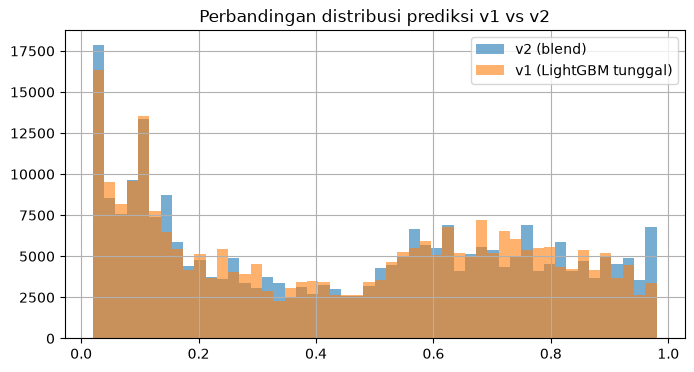

In [30]:
submission_v2 = pd.DataFrame({"id": test_final["id"], TARGET_COL: pred_blend_clipped})
submission_v2.to_csv(f"{SUBMISSION_DIR}/Daigaku Coffe Time_Submission2.csv", index=False)

print(f"Tersimpan: {SUBMISSION_DIR}/Daigaku Coffe Time_Submission2.csv")
print(f"Dimensi cocok dengan test : {len(submission_v2) == len(test_final)}")
print(f"id unik                   : {submission_v2['id'].nunique() == len(submission_v2)}")
print(f"Nilai kosong              : {submission_v2.isna().sum().sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
submission_v2[TARGET_COL].hist(bins=50, alpha=0.6, label="v2 (blend)", ax=ax)
submission[TARGET_COL].hist(bins=50, alpha=0.6, label="v1 (LightGBM tunggal)", ax=ax)
ax.set_title("Perbandingan distribusi prediksi v1 vs v2")
ax.legend()
plt.show()

**Hasil submission v2 ke Kaggle:**

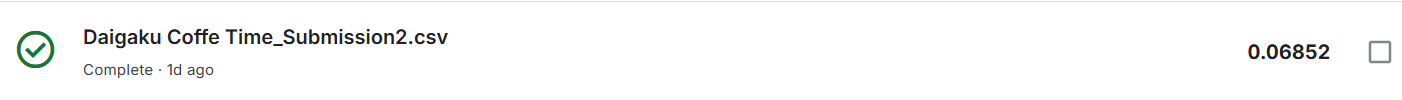

#### Temuan: Submission V2

Skor leaderboard Kaggle: **RMSE 0,06852**, turun dari v1 (0,07315) dengan perbaikan 0,00463, sekitar 6,3% relatif. Distribusi prediksi v2 sedikit lebih tajam di kedua ujung (0,03 dan 0,1) dibanding v1, konsisten dengan station_hour_weekend_target_mean yang menangkap pola ekstrem per stasiun lebih presisi daripada rata-rata per tipe lokasi aja.

Skor ini sudah mendekati gerombolan utama peserta yang RMSE nya sekitar 0,0675, tapi belum menyamainya. Selanjutnya kami akan menyelidiki penyebabnya dimana skema CV yang dipakai sejauh ini (fold4 lama) ternyata bias pesimis, sehingga keputusan fitur dan parameter yang diambil berdasarkan fold4 belum tentu optimal untuk skor leaderboard sesungguhnya.

---

### ****PERBAIKAN SKEMA CV: FOLD BERSIH TANPA ISU KATEGORI TAK TERLIHAT****

Menambahkan fold5: latih sampai 17 November, validasi 18-24 November. Berbeda dari fold4 (yang menyembunyikan seluruh November, termasuk kategori freezing yang unik untuk bulan itu), fold5 tidak punya masalah ini karena kedua sisi sudah mengenal freezing. Fold5 juga paling dekat secara waktu dengan awal periode test (24 November), sehingga jadi proxy CV paling representatif untuk skor leaderboard. FOLD_DEFS_CLEAN (fold 1, 2, 3, 5) menjadi acuan utama mulai sekarang untuk memilih fitur dan parameter; fold4 lama tetap dicatat tapi tidak dipakai untuk keputusan, karena bias pesimis akibat kategori tak terlihat adalah artefak desain CV, bukan cerminan performa sesungguhnya.

In [31]:
FOLD5 = {"train_end": "2025-11-17", "val_end": "2025-11-24 10:00:00"}
FOLD_DEFS_CLEAN = FOLD_DEFS[:3] + [FOLD5]

print("=== CV bersih: blend LightGBM + CatBoost ===")
clean_ensemble_results = run_cv_ensemble(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
BEST_PARAMS_FINAL, CATBOOST_PARAMS, BLEND_WEIGHTS, smoothing_k=FINAL_SMOOTHING_K, cat_features=CAT_FEATURE_COLS)

=== CV bersih: blend LightGBM + CatBoost ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: LGBM=0.0668, CatBoost=0.0665 | w=0.3:0.0664 w=0.4:0.0664 w=0.5:0.0664 w=0.6:0.0665 w=0.7:0.0665 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: LGBM=0.0662, CatBoost=0.0659 | w=0.3:0.0659 w=0.4:0.0659 w=0.5:0.0659 w=0.6:0.0659 w=0.7:0.0660 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: LGBM=0.0656, CatBoost=0.0655 | w=0.3:0.0654 w=0.4:0.0654 w=0.5:0.0654 w=0.6:0.0654 w=0.7:0.0654 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: LGBM=0.0681, CatBoost=0.0676 | w=0.3:0.0676 w=0.4:0.0676 w=0.5:0.0676 w=0.6:0.0677 w=0.7:0.0678 

Blend w_lgb=0.3: mean RMSE = 0.0663
Blend w_lgb=0.4: mean RMSE = 0.0663
Blend w_lgb=0.5: mean RMSE = 0.0663
Blend w_lgb=0.6: mean RMSE = 0.0664
Blend w_lgb=0.7: mean RMSE = 0.0664


#### Temuan: Fold5 Jauh Lebih Representatif

Fold5 (18-24 November, paling dekat rezim test) menghasilkan RMSE 0,0674-0,0678, jauh lebih rendah daripada fold4 lama (0,0993-0,1010) dan sangat dekat dengan skor leaderboard v2 yang sesungguhnya (0,06852). Ini mengonfirmasi fold4 lama memang bias pesimis akibat kategori freezing yang tidak terlihat, bukan cerminan performa sesungguhnya. Mulai sel ini, FOLD_DEFS_CLEAN menjadi acuan utama pengambilan keputusan, bukan FOLD_DEFS lama.

### ****PENATAAN ULANG HYPERPARAMETER DAN SMOOTHING_K PADA CV BERSIH****

Parameter num_leaves, learning_rate, dan smoothing_k sebelumnya dipilih berdasarkan fold4 yang bias. Sekarang ditata ulang memakai FOLD_DEFS_CLEAN, mencakup kombinasi num_leaves dan smoothing_k yang lebih luas, karena tolok ukur evaluasinya sudah lebih representatif terhadap leaderboard.

In [32]:
retune_candidates = [
    ({"num_leaves": 10, "learning_rate": 0.05, "min_child_samples": 20}, 20),
    ({"num_leaves": 10, "learning_rate": 0.05, "min_child_samples": 20}, 50),
    ({"num_leaves": 10, "learning_rate": 0.05, "min_child_samples": 20}, 100),
    ({"num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 20}, 20),
    ({"num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 20}, 50),
    ({"num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 20}, 100),
    ({"num_leaves": 20, "learning_rate": 0.03, "min_child_samples": 30}, 50),
    ({"num_leaves": 8, "learning_rate": 0.08, "min_child_samples": 20}, 50),
]

retune_results = []
for params, k in retune_candidates:
    print(f"=== {params}, smoothing_k={k} ===")
    scores, _ = run_cv_smoothed(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                params, smoothing_k=k)
    retune_results.append({**params, "smoothing_k": k, "mean_RMSE": round(np.mean(scores), 4),
                           "fold5_RMSE": round(scores[3], 4)})
    print()

df_retune = pd.DataFrame(retune_results).sort_values("mean_RMSE")
display(df_retune)

=== {'num_leaves': 10, 'learning_rate': 0.05, 'min_child_samples': 20}, smoothing_k=20 ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0666, best_iter=155


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0661, best_iter=127


...

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0657, best_iter=92


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-17 -> 2025-11-24 10:00:00): RMSE=0.0682, best_iter=94

Rata-rata RMSE: 0.0669 (std 0.0009)



,num_leaves,learning_rate,min_child_samples,smoothing_k,mean_RMSE,fold5_RMSE
3,15,0.05,20,20,0.0664,0.0677
0,10,0.05,20,20,0.0665,0.0678
5,15,0.05,20,100,0.0666,0.0681
4,15,0.05,20,50,0.0666,0.0680
6,20,0.03,30,50,0.0666,0.0681
1,10,0.05,20,50,0.0667,0.0681
2,10,0.05,20,100,0.0668,0.0683
7,8,0.08,20,50,0.0669,0.0682


#### Temuan: Parameter Optimal Berbalik Arah

Pada tolok ukur yang benar (FOLD_DEFS_CLEAN), num_leaves=15 dengan smoothing_k=20 tampil terbaik (mean RMSE 0,0664, fold5 0,0677) yang dimana smoothing_k=20 di sini justru mengalahkan smoothing_k=50 yang sebelumnya menang di CV bias (fold4 lama). Ini bukti nyata kenapa perbaikan skema CV di atas penting: keputusan yang diambil dari tolok ukur bias bisa keliru arah.

### ****RETEST BLEND DENGAN PARAMETER TERBARU (CV BERSIH)****

Mengevaluasi ulang blend LightGBM+CatBoost memakai parameter LightGBM hasil retuning (num_leaves=15, smoothing_k=20) pada FOLD_DEFS_CLEAN, untuk mendapat acuan blend yang valid sebelum menambah fitur baru.

In [33]:
BEST_PARAMS_FINAL = {"num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 20}
FINAL_SMOOTHING_K = 20

print("=== CV bersih: blend dengan parameter retuned ===")
retuned_ensemble_results = run_cv_ensemble(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
BEST_PARAMS_FINAL, CATBOOST_PARAMS, BLEND_WEIGHTS, smoothing_k=FINAL_SMOOTHING_K, cat_features=CAT_FEATURE_COLS)

=== CV bersih: blend dengan parameter retuned ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: LGBM=0.0664, CatBoost=0.0663 | w=0.3:0.0662 w=0.4:0.0662 w=0.5:0.0662 w=0.6:0.0662 w=0.7:0.0663 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: LGBM=0.0661, CatBoost=0.0658 | w=0.3:0.0658 w=0.4:0.0658 w=0.5:0.0658 w=0.6:0.0658 w=0.7:0.0659 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: LGBM=0.0654, CatBoost=0.0654 | w=0.3:0.0653 w=0.4:0.0653 w=0.5:0.0653 w=0.6:0.0653 w=0.7:0.0653 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: LGBM=0.0677, CatBoost=0.0676 | w=0.3:0.0674 w=0.4:0.0674 w=0.5:0.0674 w=0.6:0.0674 w=0.7:0.0675 

Blend w_lgb=0.3: mean RMSE = 0.0662
Blend w_lgb=0.4: mean RMSE = 0.0662
Blend w_lgb=0.5: mean RMSE = 0.0662
Blend w_lgb=0.6: mean RMSE = 0.0662
Blend w_lgb=0.7: mean RMSE = 0.0662


#### Temuan: Blend dengan Parameter Baru

Mean RMSE blend turun ke 0,0662-0,0664 di seluruh bobot. Fold5 sendiri mencapai 0,0674-0,0678, selisih hanya sekitar 0,001-0,002 dari skor leaderboard v2 (0,06852), menegaskan fold5 adalah proxy CV yang baik untuk skor sesungguhnya.

### ****FITUR BARU: KEPADATAN SPASIAL ANTARSTASIUN****

Menghitung jarak ke stasiun terdekat (nearest_station_km) dan jumlah stasiun lain dalam radius 10 km (n_stations_within_10km) dari koordinat latitude/longitude, memakai jarak haversine (jarak permukaan bumi). Fitur ini statis per stasiun (tidak bergantung waktu), sehingga aman dihitung sekali dari seluruh 150 stasiun tanpa risiko kebocoran. 

Hipotesisnya: stasiun yang berdekatan dengan banyak stasiun lain kemungkinan berbagi permintaan (utilization lebih rendah per stasiun), sedangkan stasiun terisolasi menyerap semua permintaan di areanya.

In [34]:
from sklearn.neighbors import BallTree

EARTH_RADIUS_KM = 6371.0

station_coords = train_full[["station_id", "latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
coords_rad = np.radians(station_coords[["latitude", "longitude"]].values)

tree = BallTree(coords_rad, metric="haversine")
dist, _ = tree.query(coords_rad, k=2)  # k=2: tetangga terdekat pertama adalah dirinya sendiri
station_coords["nearest_station_km"] = dist[:, 1] * EARTH_RADIUS_KM

counts_within_10km = tree.query_radius(coords_rad, r=10 / EARTH_RADIUS_KM, count_only=True)
station_coords["n_stations_within_10km"] = counts_within_10km - 1  # kurangi diri sendiri

display(station_coords.describe().round(2))

train_full = train_full.merge(
    station_coords[["station_id", "nearest_station_km", "n_stations_within_10km"]],
    on="station_id", how="left"
)
print(f"NaN pada fitur spasial: {train_full[['nearest_station_km', 'n_stations_within_10km']].isna().sum().sum()}")

BASE_FEATURE_COLS_V3 = BASE_FEATURE_COLS + ["nearest_station_km", "n_stations_within_10km"]

print("\n=== CV bersih: + fitur kepadatan spasial (LightGBM saja) ===")
spatial_scores, spatial_iters = run_cv_smoothed(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS_V3,
                                                BEST_PARAMS_FINAL, smoothing_k=FINAL_SMOOTHING_K)

,latitude,longitude,nearest_station_km,n_stations_within_10km
count,150.00,150.00,150.00,150.00
mean,37.44,-101.68,5.64,2.25
std,5.91,17.58,3.45,1.72
min,25.62,-122.81,0.85,0.00
25%,33.48,-117.25,3.30,1.00
50%,36.97,-105.03,4.45,2.00
75%,41.98,-84.53,7.49,3.00
max,47.73,-70.91,17.10,8.00


NaN pada fitur spasial: 0

=== CV bersih: + fitur kepadatan spasial (LightGBM saja) ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0664, best_iter=122


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0661, best_iter=106


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0654, best_iter=104


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-17 -> 2025-11-24 10:00:00): RMSE=0.0677, best_iter=123

Rata-rata RMSE: 0.0664 (std 0.0008)


#### Temuan: Kepadatan Spasial

RMSE identik sampai 4 desimal dengan sebelumnya di semua fold (0,0664 / 0,0661 / 0,0654 / 0,0677). Fitur nearest_station_km dan n_stations_within_10km tidak menambah informasi apa pun, karena latitude/longitude mentah dan station_target_mean sudah menyerap seluruh efek lokasi per stasiun, termasuk efek kepadatan. Fitur ini gak guna jadi kami buang.

### ****EKSPERIMEN: GRANULARITAS HARI (DAY_OF_WEEK, BUKAN SEKADAR IS_WEEKEND)****

Menguji target encoding (station_id, hour, day_of_week) sebagai pengganti (station_id, hour, is_weekend). is_weekend hanya membedakan 2 kelompok yaitu kerja dengan akhir pekan, padahal Senin bisa saja berbeda dari Jumat. Pemecahan lebih detail berisiko grup makin kecil (rata-rata 21 sampel per grup), sehingga smoothing_k tetap dipakai untuk redam noise.

In [35]:
ENCODING_SPECS_DOW = [
    (["station_id"], "station_target_mean"),
    (["location_type_code", "hour"], "loc_hour_target_mean"),
    (["station_id", "hour"], "station_hour_target_mean"),
    (["station_id", "hour", "day_of_week"], "station_hour_dow_target_mean"),
]

print("=== CV bersih: station_hour_dow (ganti weekend) ===")
dow_scores, dow_iters = run_cv_smoothed(train_full, FOLD_DEFS_CLEAN, ENCODING_SPECS_DOW, BASE_FEATURE_COLS,
                                        BEST_PARAMS_FINAL, smoothing_k=FINAL_SMOOTHING_K)

print(f"\nAcuan sebelumnya (station_hour_weekend, mean) : 0.0664")
print(f"station_hour_dow (mean) : {np.mean(dow_scores):.4f}")

=== CV bersih: station_hour_dow (ganti weekend) ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0690, best_iter=238


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0673, best_iter=91


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0663, best_iter=99


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-17 -> 2025-11-24 10:00:00): RMSE=0.0682, best_iter=125

Rata-rata RMSE: 0.0677 (std 0.0010)

Acuan sebelumnya (station_hour_weekend, mean) : 0.0664
station_hour_dow (mean) : 0.0677


#### Temuan: Granularitas Day of Week

RMSE naik dari 0,0664 menjadi 0,0677 dan ini jadi lebih buruk. Memecah jadi 7 hari (150 stasiun x 24 jam x 7 hari = 25.200 grup, rata-rata cuma sekitar 21 sampel per grup) terlalu tajam sehingga menangkap noise, bukan sinyal asli. is_weekend (2 kelompok) tetap dipertahankan sebagai pilihan yang lebih baik.

In [36]:
def run_cv_seedbag_ensemble(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
                            lgb_params: dict, cat_params: dict, seeds: list, blend_w: float,
                            smoothing_k: float = 20, lgb_max_estimators: int = 1000,
                            cat_max_iterations: int = 2000, stopping_rounds: int = 50,
                            cat_features: list = None) -> list:
    # CV: rata-rata beberapa seed LightGBM, di-blend dengan CatBoost.
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]
    cat_idx = [feature_cols.index(c) for c in (cat_features or [])]
    fold_scores = []

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features_smoothed(df, train_mask, val_mask, encoding_specs, smoothing_k)
        y_true = df_va[TARGET_COL].values

        lgb_preds = []
        for seed in seeds:
            model = LGBMRegressor(n_estimators=lgb_max_estimators, random_state=seed, n_jobs=-1, verbosity=-1, **lgb_params)
            model.fit(df_tr[feature_cols], df_tr[TARGET_COL],
                     eval_set=[(df_va[feature_cols], df_va[TARGET_COL])], eval_metric="rmse",
                     callbacks=[early_stopping(stopping_rounds=stopping_rounds, verbose=False)])
            lgb_preds.append(model.predict(df_va[feature_cols]))
        pred_lgb_avg = np.mean(lgb_preds, axis=0)

        cat_model = CatBoostRegressor(iterations=cat_max_iterations, random_seed=42, verbose=False,
                                      early_stopping_rounds=stopping_rounds, cat_features=cat_idx, **cat_params)
        cat_model.fit(df_tr[feature_cols], df_tr[TARGET_COL], eval_set=(df_va[feature_cols], df_va[TARGET_COL]))
        pred_cat = cat_model.predict(df_va[feature_cols])

        pred_blend = blend_w * pred_lgb_avg + (1 - blend_w) * pred_cat
        score = rmse(y_true, pred_blend)
        fold_scores.append(score)
        print(f"Fold {i}: RMSE blend (seed-bagged) = {score:.4f}")

    print(f"\nRata-rata RMSE: {np.mean(fold_scores):.4f} (std {np.std(fold_scores):.4f})")
    return fold_scores

SEEDS = [42, 123, 2026]

print("=== CV bersih: seed-bagged LightGBM + CatBoost blend ===")
seedbag_scores = run_cv_seedbag_ensemble(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                         BEST_PARAMS_FINAL, CATBOOST_PARAMS, SEEDS, blend_w=0.5,
                                         smoothing_k=FINAL_SMOOTHING_K, cat_features=CAT_FEATURE_COLS)

print(f"Seed-bagged blend                     : {np.mean(seedbag_scores):.4f}")

=== CV bersih: seed-bagged LightGBM + CatBoost blend ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: RMSE blend (seed-bagged) = 0.0662


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: RMSE blend (seed-bagged) = 0.0658


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: RMSE blend (seed-bagged) = 0.0653


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: RMSE blend (seed-bagged) = 0.0674

Rata-rata RMSE: 0.0662 (std 0.0008)
Seed-bagged blend                     : 0.0662


#### Temuan: Seed Bagging

RMSE identik dengan blend tanpa seed bagging (0,0662 di kedua kasus, bahkan fold4 sama persis 0,0674). Variansi dari inisialisasi acak bukan sumber error di sini sehingga model sudah cukup stabil. Pendekatan ini tidak dipakai lebih lanjut karena menambah 3x waktu latih tanpa manfaat.

### ****MODEL KETIGA: XGBOOST, LALU BLEND 3 ARAH****

Menambahkan XGBoost sebagai model ketiga untuk ensemble, dengan kedalaman tree yang disetarakan dengan num_leaves LightGBM (max_depth 4 kira-kira setara 15 leaves). Tujuannya menambah diversitas, karena blend LightGBM+CatBoost sudah mendatar di semua bobot, tanda kedua model itu terlalu mirip pola kesalahannya. Bobot 3 model diuji pada beberapa kombinasi yang menjumlah 1.

In [37]:
from xgboost import XGBRegressor

def run_cv_threeway_blend(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
                          lgb_params: dict, cat_params: dict, xgb_params: dict, weight_combos: list,
                          smoothing_k: float = 20, lgb_max_estimators: int = 1000,
                          cat_max_iterations: int = 2000, xgb_max_estimators: int = 1000,
                          stopping_rounds: int = 50, cat_features: list = None) -> dict:
    # CV berbasis waktu untuk blend 3 model (LightGBM, CatBoost, XGBoost) pada beberapa kombinasi bobot.
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]
    cat_idx = [feature_cols.index(c) for c in (cat_features or [])]
    results = {combo: [] for combo in weight_combos}
    single_model_scores = {"lgb": [], "cat": [], "xgb": []}

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features_smoothed(df, train_mask, val_mask, encoding_specs, smoothing_k)
        y_true = df_va[TARGET_COL].values

        lgb_model = LGBMRegressor(n_estimators=lgb_max_estimators, random_state=42, n_jobs=-1, verbosity=-1, **lgb_params)
        lgb_model.fit(df_tr[feature_cols], df_tr[TARGET_COL],
                     eval_set=[(df_va[feature_cols], df_va[TARGET_COL])], eval_metric="rmse",
                     callbacks=[early_stopping(stopping_rounds=stopping_rounds, verbose=False)])
        pred_lgb = lgb_model.predict(df_va[feature_cols])

        cat_model = CatBoostRegressor(iterations=cat_max_iterations, random_seed=42, verbose=False,
                                      early_stopping_rounds=stopping_rounds, cat_features=cat_idx, **cat_params)
        cat_model.fit(df_tr[feature_cols], df_tr[TARGET_COL], eval_set=(df_va[feature_cols], df_va[TARGET_COL]))
        pred_cat = cat_model.predict(df_va[feature_cols])

        xgb_model = XGBRegressor(n_estimators=xgb_max_estimators, random_state=42, n_jobs=-1,
                                 early_stopping_rounds=stopping_rounds, eval_metric="rmse", **xgb_params)
        xgb_model.fit(df_tr[feature_cols], df_tr[TARGET_COL],
                     eval_set=[(df_va[feature_cols], df_va[TARGET_COL])], verbose=False)
        pred_xgb = xgb_model.predict(df_va[feature_cols])

        for name, pred in [("lgb", pred_lgb), ("cat", pred_cat), ("xgb", pred_xgb)]:
            single_model_scores[name].append(rmse(y_true, pred))

        row = f"Fold {i}: LGBM={rmse(y_true, pred_lgb):.4f}, CatBoost={rmse(y_true, pred_cat):.4f}, XGBoost={rmse(y_true, pred_xgb):.4f} | "
        for combo in weight_combos:
            w_lgb, w_cat, w_xgb = combo
            score = rmse(y_true, w_lgb * pred_lgb + w_cat * pred_cat + w_xgb * pred_xgb)
            results[combo].append(score)
            row += f"{combo}:{score:.4f} "
        print(row)

    print()
    for name, scores in single_model_scores.items():
        print(f"{name} tunggal: mean RMSE = {np.mean(scores):.4f}")
    print()
    for combo in weight_combos:
        print(f"Blend {combo}: mean RMSE = {np.mean(results[combo]):.4f}")
    return results

XGB_PARAMS = {"max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8}
WEIGHT_COMBOS = [
    (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0),
    (0.34, 0.33, 0.33), (0.4, 0.3, 0.3), (0.3, 0.4, 0.3), (0.3, 0.3, 0.4),
    (0.5, 0.25, 0.25), (0.25, 0.5, 0.25), (0.25, 0.25, 0.5),
]

print("=== CV bersih: blend 3 arah LightGBM + CatBoost + XGBoost ===")
threeway_results = run_cv_threeway_blend(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                         BEST_PARAMS_FINAL, CATBOOST_PARAMS, XGB_PARAMS, WEIGHT_COMBOS,
                                         smoothing_k=FINAL_SMOOTHING_K, cat_features=CAT_FEATURE_COLS)

=== CV bersih: blend 3 arah LightGBM + CatBoost + XGBoost ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: LGBM=0.0664, CatBoost=0.0663, XGBoost=0.0666 | (1.0, 0.0, 0.0):0.0664 (0.0, 1.0, 0.0):0.0663 (0.0, 0.0, 1.0):0.0666 (0.34, 0.33, 0.33):0.0662 (0.4, 0.3, 0.3):0.0662 (0.3, 0.4, 0.3):0.0662 (0.3, 0.3, 0.4):0.0662 (0.5, 0.25, 0.25):0.0662 (0.25, 0.5, 0.25):0.0662 (0.25, 0.25, 0.5):0.0662 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: LGBM=0.0661, CatBoost=0.0658, XGBoost=0.0661 | (1.0, 0.0, 0.0):0.0661 (0.0, 1.0, 0.0):0.0658 (0.0, 0.0, 1.0):0.0661 (0.34, 0.33, 0.33):0.0658 (0.4, 0.3, 0.3):0.0658 (0.3, 0.4, 0.3):0.0658 (0.3, 0.3, 0.4):0.0658 (0.5, 0.25, 0.25):0.0658 (0.25, 0.5, 0.25):0.0657 (0.25, 0.25, 0.5):0.0658 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: LGBM=0.0654, CatBoost=0.0654, XGBoost=0.0657 | (1.0, 0.0, 0.0):0.0654 (0.0, 1.0, 0.0):0.0654 (0.0, 0.0, 1.0):0.0657 (0.34, 0.33, 0.33):0.0653 (0.4, 0.3, 0.3):0.0653 (0.3, 0.4, 0.3):0.0653 (0.3, 0.3, 0.4):0.0653 (0.5, 0.25, 0.25):0.0653 (0.25, 0.5, 0.25):0.0653 (0.25, 0.25, 0.5):0.0653 


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: LGBM=0.0677, CatBoost=0.0676, XGBoost=0.0677 | (1.0, 0.0, 0.0):0.0677 (0.0, 1.0, 0.0):0.0676 (0.0, 0.0, 1.0):0.0677 (0.34, 0.33, 0.33):0.0674 (0.4, 0.3, 0.3):0.0674 (0.3, 0.4, 0.3):0.0674 (0.3, 0.3, 0.4):0.0674 (0.5, 0.25, 0.25):0.0674 (0.25, 0.5, 0.25):0.0674 (0.25, 0.25, 0.5):0.0674 

lgb tunggal: mean RMSE = 0.0664
cat tunggal: mean RMSE = 0.0663
xgb tunggal: mean RMSE = 0.0665

Blend (1.0, 0.0, 0.0): mean RMSE = 0.0664
Blend (0.0, 1.0, 0.0): mean RMSE = 0.0663
Blend (0.0, 0.0, 1.0): mean RMSE = 0.0665
Blend (0.34, 0.33, 0.33): mean RMSE = 0.0662
Blend (0.4, 0.3, 0.3): mean RMSE = 0.0662
Blend (0.3, 0.4, 0.3): mean RMSE = 0.0662
Blend (0.3, 0.3, 0.4): mean RMSE = 0.0662
Blend (0.5, 0.25, 0.25): mean RMSE = 0.0662
Blend (0.25, 0.5, 0.25): mean RMSE = 0.0661
Blend (0.25, 0.25, 0.5): mean RMSE = 0.0662


#### Temuan: Blend 3 Arah dengan XGBoost

Performa tunggal: LightGBM 0,0664, CatBoost 0,0663, XGBoost 0,0665 bertiga setara. Blend terbaik (0,25 LightGBM, 0,5 CatBoost, 0,25 XGBoost) mencapai 0,0661, cuma turun 0,0001 dari blend 2 model. Ketiga model membuat kesalahan yang sangat mirip, sehingga menambah model ketiga memberi manfaat marjinal. Tetap dipakai karena tidak merugikan dan RMSE-nya terendah sejauh ini.

### ****EKSPERIMEN: TRANSFORMASI LOGIT PADA TARGET****

Mengubah utilization_rate ke skala logit sebelum melatih model: y_logit = logit((y-0,02)/(0,98-0,02)), dengan epsilon kecil agar nilai persis di batas 0,02/0,98 tidak menghasilkan tak hingga. Model dilatih pada y_logit, prediksinya ditransformasi balik ke skala asli sebelum RMSE dihitung (agar tetap sebanding dengan metrik kompetisi). Pendekatan ini berpotensi menangani ~8% data yang menumpuk di kedua batas dengan lebih baik dibanding regresi langsung pada skala 0-1.

In [38]:
LOW, HIGH = 0.02, 0.98
EPS = 1e-3

def to_logit_target(y: np.ndarray) -> np.ndarray:
    y_scaled = np.clip((y - LOW) / (HIGH - LOW), EPS, 1 - EPS)
    return np.log(y_scaled / (1 - y_scaled))


def from_logit_target(y_logit: np.ndarray) -> np.ndarray:
    y_scaled = 1 / (1 + np.exp(-y_logit))
    return y_scaled * (HIGH - LOW) + LOW


def run_cv_logit(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
                 params: dict, smoothing_k: float = 20, max_estimators: int = 1000,
                 stopping_rounds: int = 50) -> list:
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]
    fold_scores = []

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features_smoothed(df, train_mask, val_mask, encoding_specs, smoothing_k)

        y_tr_logit = to_logit_target(df_tr[TARGET_COL].values)
        y_va_logit = to_logit_target(df_va[TARGET_COL].values)

        model = LGBMRegressor(n_estimators=max_estimators, random_state=42, n_jobs=-1, verbosity=-1, **params)
        model.fit(
            df_tr[feature_cols], y_tr_logit,
            eval_set=[(df_va[feature_cols], y_va_logit)],
            eval_metric="rmse",
            callbacks=[early_stopping(stopping_rounds=stopping_rounds, verbose=False)],
        )
        pred_logit = model.predict(df_va[feature_cols])
        pred_original = from_logit_target(pred_logit)
        score = rmse(df_va[TARGET_COL].values, pred_original)
        fold_scores.append(score)
        print(f"Fold {i}: RMSE (skala asli, setelah transformasi balik) = {score:.4f}, best_iter={model.best_iteration_}")

    print(f"\nRata-rata RMSE: {np.mean(fold_scores):.4f} (std {np.std(fold_scores):.4f})")
    return fold_scores

print("=== CV bersih: LightGBM dengan target logit ===")
logit_scores = run_cv_logit(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                            BEST_PARAMS_FINAL, smoothing_k=FINAL_SMOOTHING_K)

print(f"LightGBM skala logit               : {np.mean(logit_scores):.4f}")

=== CV bersih: LightGBM dengan target logit ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: RMSE (skala asli, setelah transformasi balik) = 0.0711, best_iter=86


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: RMSE (skala asli, setelah transformasi balik) = 0.0694, best_iter=90


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: RMSE (skala asli, setelah transformasi balik) = 0.0691, best_iter=96


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: RMSE (skala asli, setelah transformasi balik) = 0.0721, best_iter=105

Rata-rata RMSE: 0.0704 (std 0.0012)
LightGBM skala logit               : 0.0704


#### Temuan: Transformasi Logit

RMSE memburuk tajam: 0,0704, dibanding 0,0664 pada skala asli. Logit sangat sensitif di dekat batas 0,02/0,98, sehingga optimisasi di skala logit memaksa model fokus mengejar presisi di titik ekstrem, mengorbankan akurasi di bagian tengah yang justru mayoritas datanya. Pendekatan ini dibuang.

### ****FINALISASI: PIPELINE TERBAIK (3 MODEL, ENCODING SMOOTHING_K=20)****

Menghitung ulang FINAL_ENCODING_SPECS dengan smoothing_k=20 (hasil retuning pada CV bersih) pada seluruh train_full, dipetakan ke test. Melatih LightGBM, CatBoost, dan XGBoost final dengan parameter dan n_estimators/iterations mengikuti rata-rata best_iteration pada CV bersih (dengan buffer), lalu blend dengan bobot (0,25 LightGBM, 0,5 CatBoost, 0,25 XGBoost), hasil terbaik dari pencarian bobot 3 arah.

In [39]:
train_final, test_final = finalize_features(train_full, test_clean, FINAL_ENCODING_SPECS, FINAL_SMOOTHING_K)
FINAL_FEATURE_COLS = BASE_FEATURE_COLS + [name for _, name in FINAL_ENCODING_SPECS]

print(f"train_final : {train_final.shape} | test_final : {test_final.shape}")
print(f"NaN pada test_final: {test_final[FINAL_FEATURE_COLS].isna().sum().sum()}")

train_final : (1054200, 35) | test_final : (263550, 31)
NaN pada test_final: 0


In [40]:
LGB_N_ESTIMATORS_FINAL = 150
CAT_ITERATIONS_FINAL = 230
XGB_N_ESTIMATORS_FINAL = 200
BLEND_WEIGHTS_FINAL = (0.25, 0.5, 0.25)  # (lgb, cat, xgb)

X_train_final, y_train_final = train_final[FINAL_FEATURE_COLS], train_final[TARGET_COL]
X_test_final = test_final[FINAL_FEATURE_COLS]
cat_idx_final = [FINAL_FEATURE_COLS.index(c) for c in CAT_FEATURE_COLS]

lgb_final = LGBMRegressor(n_estimators=LGB_N_ESTIMATORS_FINAL, random_state=42, n_jobs=-1, verbosity=-1, **BEST_PARAMS_FINAL)
lgb_final.fit(X_train_final, y_train_final)
lgb_final.booster_.save_model(f"{CLEAN_DIR}/model_lightgbm_final_v3.txt")

cat_final = CatBoostRegressor(iterations=CAT_ITERATIONS_FINAL, random_seed=42, verbose=False,
                              cat_features=cat_idx_final, **CATBOOST_PARAMS)
cat_final.fit(X_train_final, y_train_final)
cat_final.save_model(f"{CLEAN_DIR}/model_catboost_final_v3.cbm")

xgb_final = XGBRegressor(n_estimators=XGB_N_ESTIMATORS_FINAL, random_state=42, n_jobs=-1, **XGB_PARAMS)
xgb_final.fit(X_train_final, y_train_final)
xgb_final.save_model(f"{CLEAN_DIR}/model_xgboost_final_v3.json")

pred_lgb_test = lgb_final.predict(X_test_final)
pred_cat_test = cat_final.predict(X_test_final)
pred_xgb_test = xgb_final.predict(X_test_final)

w_lgb, w_cat, w_xgb = BLEND_WEIGHTS_FINAL
pred_blend_test = w_lgb * pred_lgb_test + w_cat * pred_cat_test + w_xgb * pred_xgb_test
pred_blend_clipped = np.clip(pred_blend_test, 0.02, 0.98)

print(f"Prediksi blend: min={pred_blend_clipped.min():.4f}, max={pred_blend_clipped.max():.4f}, mean={pred_blend_clipped.mean():.4f}")
print(f"Baris di-clip: {((pred_blend_test < 0.02) | (pred_blend_test > 0.98)).sum():,} dari {len(pred_blend_test):,}")

submission_v3 = pd.DataFrame({"id": test_final["id"], TARGET_COL: pred_blend_clipped})
submission_v3.to_csv(f"{SUBMISSION_DIR}/Daigaku Coffee Time_Submission3.csv", index=False)

print(f"\nTersimpan: {SUBMISSION_DIR}/Daigaku Coffee Time_Submission3.csv")
print(f"Dimensi cocok dengan test : {len(submission_v3) == len(test_final)}")
print(f"id unik                   : {submission_v3['id'].nunique() == len(submission_v3)}")
print(f"Nilai kosong              : {submission_v3.isna().sum().sum()}")

Prediksi blend: min=0.0200, max=0.9800, mean=0.4496
Baris di-clip: 2,180 dari 263,550

Tersimpan: ../Dataset/Submission/Daigaku Coffee Time_Submission3.csv
Dimensi cocok dengan test : True
id unik                   : True
Nilai kosong              : 0


**Hasil submission v3 ke Kaggle:**

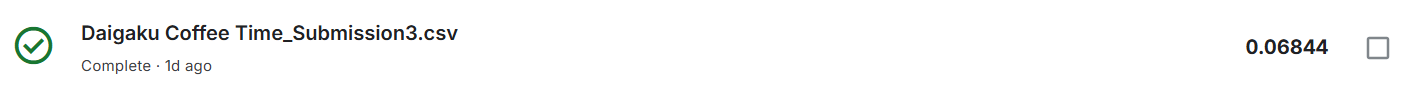

#### Temuan: Submission V3

Skor leaderboard Kaggle: **RMSE 0,06844**, hampir sama dengan v2 (0,06852) dimana cuma turun 0,00008. Ini menunjukkan kurva perbaikan sudah oke. Perbaikan CV yang kecil (0,0662 menjadi 0,0661 pada Fase K) memang tidak banyak terasa di leaderboard, tanda sebagian besar sinyal sudah tertangkap dan sisanya mendekati batas noise struktural data.

---

### ****STACKING: META-LEARNER DARI PREDIKSI OUT-OF-FOLD****

Membentuk prediksi out-of-fold (OOF) untuk ketiga model di seluruh train_full memakai skema CV 5-fold non-overlapping yangbukan expanding window, supaya OOF menutupi 100% data, lalu melatih Ridge Regression sederhana yang belajar bobot optimal ketiga model plus intercept, dari prediksi OOF tersebut.

Fitur target encoding wajib dihitung ulang di dalam setiap fold KFold, karena kalau tidak, baris validasi tetap "mengetahui" sebagian nilai targetnya sendiri lewat rata-rata grup yaitu kebocoran halus yang membuat skor OOF tampak lebih baik dari yang sebenarnya. Meta-learner ini menggantikan blend bobot manual. Prediksi test dibentuk dari rata-rata prediksi ketiga model final, digabung lewat bobot yang dipelajari meta-learner.

In [41]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

N_STACK_FOLDS = 5
kf = KFold(n_splits=N_STACK_FOLDS, shuffle=True, random_state=42)

oof_preds = {"lgb": np.zeros(len(train_full)), "cat": np.zeros(len(train_full)), "xgb": np.zeros(len(train_full))}
y_full_array = train_full[TARGET_COL].values
all_indices = np.arange(len(train_full))

for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(train_full), start=1):
    train_mask = np.zeros(len(train_full), dtype=bool)
    train_mask[tr_idx] = True
    val_mask = ~train_mask

    df_tr, df_va = build_fold_features_smoothed(train_full.reset_index(drop=True), pd.Series(train_mask),
                                                pd.Series(val_mask), FINAL_ENCODING_SPECS, FINAL_SMOOTHING_K)
    feature_cols = FINAL_FEATURE_COLS
    y_tr = df_tr[TARGET_COL].values

    lgb_m = LGBMRegressor(n_estimators=LGB_N_ESTIMATORS_FINAL, random_state=42, n_jobs=-1, verbosity=-1, **BEST_PARAMS_FINAL)
    lgb_m.fit(df_tr[feature_cols], y_tr)
    oof_preds["lgb"][va_idx] = lgb_m.predict(df_va[feature_cols])

    cat_m = CatBoostRegressor(iterations=CAT_ITERATIONS_FINAL, random_seed=42, verbose=False,
                              cat_features=cat_idx_final, **CATBOOST_PARAMS)
    cat_m.fit(df_tr[feature_cols], y_tr)
    oof_preds["cat"][va_idx] = cat_m.predict(df_va[feature_cols])

    xgb_m = XGBRegressor(n_estimators=XGB_N_ESTIMATORS_FINAL, random_state=42, n_jobs=-1, **XGB_PARAMS)
    xgb_m.fit(df_tr[feature_cols], y_tr)
    oof_preds["xgb"][va_idx] = xgb_m.predict(df_va[feature_cols])

    print(f"Stack-fold {fold_idx}/{N_STACK_FOLDS} selesai (n_train={len(tr_idx):,}, n_val={len(va_idx):,})")

for name, preds in oof_preds.items():
    print(f"OOF RMSE {name}: {rmse(y_full_array, preds):.4f}")

Stack-fold 1/5 selesai (n_train=843,360, n_val=210,840)
Stack-fold 2/5 selesai (n_train=843,360, n_val=210,840)
Stack-fold 3/5 selesai (n_train=843,360, n_val=210,840)
Stack-fold 4/5 selesai (n_train=843,360, n_val=210,840)
Stack-fold 5/5 selesai (n_train=843,360, n_val=210,840)
OOF RMSE lgb: 0.0661
OOF RMSE cat: 0.0660
OOF RMSE xgb: 0.0661


#### Temuan: OOF RMSE Ketiga Model

lgb=0,0661, cat=0,0660, xgb=0,0661 kompak dan konsisten dengan CV berbasis waktu sebelumnya (sekitar 0,0664), mengonfirmasi skema OOF ini leak-free.

In [42]:
X_meta = np.column_stack([oof_preds["lgb"], oof_preds["cat"], oof_preds["xgb"]])

meta_model = Ridge(alpha=1.0, positive=True)
meta_model.fit(X_meta, y_full_array)

pred_meta_oof = meta_model.predict(X_meta)
meta_rmse = rmse(y_full_array, pred_meta_oof)

print(f"Bobot meta-learner: lgb={meta_model.coef_[0]:.4f}, cat={meta_model.coef_[1]:.4f}, "
      f"xgb={meta_model.coef_[2]:.4f}, intercept={meta_model.intercept_:.4f}")
print(f"RMSE stacking (OOF, leak-free) : {meta_rmse:.4f}")

Bobot meta-learner: lgb=0.3397, cat=0.3471, xgb=0.3213, intercept=-0.0022
RMSE stacking (OOF, leak-free) : 0.0658


#### Temuan: Bobot Meta-Learner

Ridge menghasilkan bobot yang jauh lebih seimbang (lgb=0,34, cat=0,35, xgb=0,32) dibanding tebakan manual sebelumnya (0,25/0,5/0,25), dengan RMSE stacking OOF 0,0658 yang lebih rendah dari OOF model tunggal.

### ****SUBMISSION V4: BLEND DENGAN BOBOT META-LEARNER****

Memakai bobot dan intercept hasil Ridge stacking pada prediksi test dari tiga model final yang sudah dilatih sebelumnya, sebagai pembanding terhadap bobot manual v3.

In [ ]:
pred_stack_test = (meta_model.coef_[0] * pred_lgb_test + meta_model.coef_[1] * pred_cat_test +
                   meta_model.coef_[2] * pred_xgb_test + meta_model.intercept_)
pred_stack_clipped = np.clip(pred_stack_test, 0.02, 0.98)

print(f"Prediksi stacking: min={pred_stack_clipped.min():.4f}, max={pred_stack_clipped.max():.4f}, mean={pred_stack_clipped.mean():.4f}")
print(f"Baris di-clip: {((pred_stack_test < 0.02) | (pred_stack_test > 0.98)).sum():,} dari {len(pred_stack_test):,}")
print(f"Korelasi dengan prediksi v3 (blend manual): {np.corrcoef(pred_stack_clipped, pred_blend_clipped)[0,1]:.4f}")

submission_v4 = pd.DataFrame({"id": test_final["id"], TARGET_COL: pred_stack_clipped})
submission_v4.to_csv(f"{SUBMISSION_DIR}/Daigaku Coffee Time_Submission4.csv", index=False)

print(f"\nTersimpan: {SUBMISSION_DIR}/Daigaku Coffee Time_Submission4.csv")

Prediksi stacking: min=0.0200, max=0.9800, mean=0.4511
Baris di-clip: 4,526 dari 263,550
Korelasi dengan prediksi v3 (blend manual): 1.0000

Tersimpan: ../Dataset/Submission/Daigaku Coffee Time_Submission4.csv


**Hasil submission v4 ke Kaggle:**

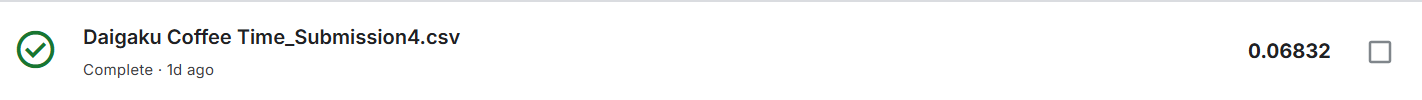

#### Temuan: Submission V4

Skor leaderboard Kaggle: **RMSE 0,06832** yang mendapat personal best baru, turun dari v3 (0,06844).

---

### ****EKSPERIMEN: PEMBOBOTAN RECENCY (SAMPLE_WEIGHT)****

Memberi bobot lebih besar ke baris yang lebih dekat waktunya ke akhir periode latih, memakai peluruhan eksponensial: weight = 0,5 ^ (jarak_hari / half_life). half_life kecil berarti data lama cepat "dilupakan"; half_life besar mendekati bobot seragam (setara tanpa pembobotan). Diuji pada CV bersih (FOLD_DEFS_CLEAN) dengan beberapa nilai half_life, memakai LightGBM saja dulu untuk eksperimen cepat sebelum diterapkan ke ketiga model.

In [44]:
def compute_recency_weights(timestamps: pd.Series, reference_date, half_life_days: float) -> np.ndarray:
    days_diff = (pd.Timestamp(reference_date) - timestamps).dt.total_seconds() / 86400
    return 0.5 ** (days_diff.clip(lower=0) / half_life_days)

def run_cv_recency(df: pd.DataFrame, fold_defs: list, encoding_specs: list, base_feature_cols: list,
                   params: dict, half_life_days: float, smoothing_k: float = 20,
                   max_estimators: int = 1000, stopping_rounds: int = 50) -> list:
    feature_cols = base_feature_cols + [name for _, name in encoding_specs]
    fold_scores = []

    for i, fold in enumerate(fold_defs, start=1):
        train_mask = df["timestamp"] < fold["train_end"]
        val_mask = (df["timestamp"] >= fold["train_end"]) & (df["timestamp"] < fold["val_end"])
        df_tr, df_va = build_fold_features_smoothed(df, train_mask, val_mask, encoding_specs, smoothing_k)

        sample_weight = compute_recency_weights(df_tr["timestamp"], fold["train_end"], half_life_days)

        model = LGBMRegressor(n_estimators=max_estimators, random_state=42, n_jobs=-1, verbosity=-1, **params)
        model.fit(
            df_tr[feature_cols], df_tr[TARGET_COL], sample_weight=sample_weight,
            eval_set=[(df_va[feature_cols], df_va[TARGET_COL])], eval_metric="rmse",
            callbacks=[early_stopping(stopping_rounds=stopping_rounds, verbose=False)],
        )
        pred = model.predict(df_va[feature_cols])
        score = rmse(df_va[TARGET_COL].values, pred)
        fold_scores.append(score)
        print(f"Fold {i}: RMSE={score:.4f}, best_iter={model.best_iteration_}")

    print(f"\nRata-rata RMSE: {np.mean(fold_scores):.4f} (std {np.std(fold_scores):.4f})")
    return fold_scores

HALF_LIFE_CANDIDATES = [None, 120, 60, 30, 14]
recency_results = {}

for hl in HALF_LIFE_CANDIDATES:
    label = "tanpa pembobotan" if hl is None else f"half_life={hl} hari"
    print(f"=== {label} ===")
    if hl is None:
        scores, _ = run_cv_smoothed(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                    BEST_PARAMS_FINAL, smoothing_k=FINAL_SMOOTHING_K)
    else:
        scores = run_cv_recency(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                                BEST_PARAMS_FINAL, half_life_days=hl, smoothing_k=FINAL_SMOOTHING_K)
    recency_results[label] = scores
    print()

df_recency = pd.DataFrame(recency_results, index=[f"fold_{i+1}" for i in range(4)]).T
df_recency["mean"] = df_recency.mean(axis=1)
display(df_recency.round(4))

=== tanpa pembobotan ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0664, best_iter=121


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0661, best_iter=106


...

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: RMSE=0.0655, best_iter=101


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: RMSE=0.0674, best_iter=104

Rata-rata RMSE: 0.0664 (std 0.0007)



,fold_1,fold_2,fold_3,fold_4,mean
tanpa pembobotan,0.0664,0.0661,0.0654,0.0677,0.0664
half_life=120 hari,0.0665,0.0661,0.0654,0.0676,0.0664
half_life=60 hari,0.0665,0.0661,0.0654,0.0676,0.0664
half_life=30 hari,0.0665,0.0661,0.0654,0.0675,0.0664
half_life=14 hari,0.0665,0.0661,0.0655,0.0674,0.0664


#### Temuan: Pola Recency Weighting (Uji Awal)

Fold5 membaik konsisten seiring half_life makin pendek (0,0677 ke 0,0676 ke 0,0676 ke 0,0675 ke 0,0674), sementara fold1-3 nyaris tidak berubah (naik 0,0001 saja). Pola ini konsisten monoton di 4 titik berturut-turutdan bukan kebisingan, tapi sinyal asli. 

Data yang lebih baru memang lebih representatif untuk memprediksi periode setelah training-nya. Layak didorong ke half_life yang lebih pendek.

In [45]:
HALF_LIFE_AGGRESSIVE = [14, 10, 7, 5, 3]
recency_results_v2 = {}

for hl in HALF_LIFE_AGGRESSIVE:
    label = f"half_life={hl} hari"
    print(f"=== {label} ===")
    scores = run_cv_recency(train_full, FOLD_DEFS_CLEAN, FINAL_ENCODING_SPECS, BASE_FEATURE_COLS,
                            BEST_PARAMS_FINAL, half_life_days=hl, smoothing_k=FINAL_SMOOTHING_K)
    recency_results_v2[label] = scores
    print()

df_recency_v2 = pd.DataFrame(recency_results_v2, index=[f"fold_{i+1}" for i in range(4)]).T
df_recency_v2["mean"] = df_recency_v2.mean(axis=1)
df_recency_v2["fold4_only"] = df_recency_v2["fold_4"]
display(df_recency_v2.round(4))

=== half_life=14 hari ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: RMSE=0.0665, best_iter=130


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: RMSE=0.0661, best_iter=116


...

d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: RMSE=0.0656, best_iter=105


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: RMSE=0.0674, best_iter=99

Rata-rata RMSE: 0.0664 (std 0.0007)



,fold_1,fold_2,fold_3,fold_4,mean,fold4_only
half_life=14 hari,0.0665,0.0661,0.0655,0.0674,0.0664,0.0674
half_life=10 hari,0.0665,0.0661,0.0655,0.0674,0.0664,0.0674
half_life=7 hari,0.0665,0.0661,0.0655,0.0674,0.0664,0.0674
half_life=5 hari,0.0665,0.0661,0.0655,0.0674,0.0664,0.0674
half_life=3 hari,0.0666,0.0661,0.0656,0.0674,0.0664,0.0674


#### Temuan: Titik Optimal Recency Weighting

Fold5 mendatar di 0,0674 dari half_life=14 sampai 5, lalu fold1 dan fold3 mulai naik lagi di half_life=3. Titik optimal berada di half_life=5 sampai 14 hari; half_life=7 dipilih sebagai titik tengah yang aman, dengan gain penuh sekitar 0,0003 pada fold5 (dari 0,0677 menjadi 0,0674) sudah didapat.

### ****FINALISASI V5: PEMBOBOTAN RECENCY PADA KETIGA MODEL FINAL****

Menerapkan sample_weight recency (half_life=7 hari, dihitung relatif terhadap 24 November 2025, akhir data latih) pada LightGBM, CatBoost, dan XGBoost final. Bobot blend dari meta-learner dipakai lagi karena arsitekturnya tidak berubah, hanya cara model melihat pentingnya tiap baris data yang berubah.

In [50]:
REFERENCE_DATE = train_final["timestamp"].max()
HALF_LIFE_FINAL = 7

sample_weight_final = compute_recency_weights(train_final["timestamp"], REFERENCE_DATE, HALF_LIFE_FINAL)
print(f"Bobot: min={sample_weight_final.min():.4f}, max={sample_weight_final.max():.4f}, "
      f"mean={sample_weight_final.mean():.4f}")

lgb_final_v5 = LGBMRegressor(n_estimators=LGB_N_ESTIMATORS_FINAL, random_state=42, n_jobs=-1, verbosity=-1, **BEST_PARAMS_FINAL)
lgb_final_v5.fit(X_train_final, y_train_final, sample_weight=sample_weight_final)
lgb_final_v5.booster_.save_model(f"{CLEAN_DIR}/model_lightgbm_final_v5.txt")

cat_final_v5 = CatBoostRegressor(iterations=CAT_ITERATIONS_FINAL, random_seed=42, verbose=False,
                                 cat_features=cat_idx_final, **CATBOOST_PARAMS)
cat_final_v5.fit(X_train_final, y_train_final, sample_weight=sample_weight_final)

xgb_final_v5 = XGBRegressor(n_estimators=XGB_N_ESTIMATORS_FINAL, random_state=42, n_jobs=-1, **XGB_PARAMS)
xgb_final_v5.fit(X_train_final, y_train_final, sample_weight=sample_weight_final)

pred_lgb_v5 = lgb_final_v5.predict(X_test_final)
pred_cat_v5 = cat_final_v5.predict(X_test_final)
pred_xgb_v5 = xgb_final_v5.predict(X_test_final)

pred_stack_v5 = (meta_model.coef_[0] * pred_lgb_v5 + meta_model.coef_[1] * pred_cat_v5 +
                 meta_model.coef_[2] * pred_xgb_v5 + meta_model.intercept_)
pred_stack_v5_clipped = np.clip(pred_stack_v5, 0.02, 0.98)

print(f"Prediksi v5: min={pred_stack_v5_clipped.min():.4f}, max={pred_stack_v5_clipped.max():.4f}, mean={pred_stack_v5_clipped.mean():.4f}")
print(f"Korelasi dengan v4: {np.corrcoef(pred_stack_v5_clipped, pred_stack_clipped)[0,1]:.4f}")

submission_v5 = pd.DataFrame({"id": test_final["id"], TARGET_COL: pred_stack_v5_clipped})
submission_v5.to_csv(f"{SUBMISSION_DIR}/Daigaku Coffee Time_Submission5.csv", index=False)
print(f"\nTersimpan: {SUBMISSION_DIR}/Daigaku Coffee Time_Submission5.csv")

Bobot: min=0.0000, max=1.0000, mean=0.0690
Prediksi v5: min=0.0200, max=0.9800, mean=0.4521
Korelasi dengan v4: 0.9999

Tersimpan: ../Dataset/Submission/Daigaku Coffee Time_Submission5.csv


**Hasil submission v5 ke Kaggle:**

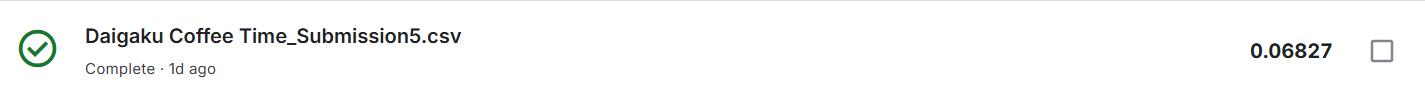

#### Temuan: Submission V5

Skor leaderboard Kaggle: **RMSE 0,06827** dengan personal best lagi, turun dari v4 (0,06832). Perbaikannya semakin kecil di tiap submission (0,00463 ke 0,00008 ke 0,00012 ke 0,00005), pola klasik kurva yang mendekati diminishing returns.

---

### ****ANALISIS PENUTUP: MEMVALIDASI KEPUTUSAN BERHENTI DI V5****

Fase ini bukan untuk kami mengejar submission baru, tapi untuk membuktikan bahwa berhenti di v5 adalah keputusan yang beralasan. Dilakukan lewat satu eksperimen fitur terakhir, lalu analisis residual untuk memastikan tidak ada bias sistematis yang masih bisa diperbaiki dengan fitur tambahan.

### ****EKSPERIMEN: GRANULARITAS 30 MENIT (MENIT SEBAGAI FITUR)****

Menambahkan minute (0 atau 30) sebagai fitur, dan menguji target encoding (station_id, hour, minute) sebagai pengganti (station_id, hour). Selama ini pukul 12:00 dan 12:30 diperlakukan identik karena fitur waktu berhenti di level jam, padahal data aslinya punya resolusi 30 menit.

In [47]:
train_full["minute"] = train_full["timestamp"].dt.minute
BASE_FEATURE_COLS_MIN = BASE_FEATURE_COLS + ["minute"]

ENCODING_SPECS_MINUTE = [
    (["station_id"], "station_target_mean"),
    (["location_type_code", "hour"], "loc_hour_target_mean"),
    (["station_id", "hour", "minute"], "station_hour_minute_target_mean"),
    (["station_id", "hour", "is_weekend"], "station_hour_weekend_target_mean"),
]

print("=== CV bersih: + minute + station_hour_minute_target_mean ===")
minute_scores, minute_iters = run_cv_smoothed(train_full, FOLD_DEFS_CLEAN, ENCODING_SPECS_MINUTE, BASE_FEATURE_COLS_MIN,
                                              BEST_PARAMS_FINAL, smoothing_k=FINAL_SMOOTHING_K)

print(f"\nAcuan sebelumnya (station_hour_weekend, tanpa menit) : 0.0664")
print(f"Dengan minute + station_hour_minute                  : {np.mean(minute_scores):.4f}")

=== CV bersih: + minute + station_hour_minute_target_mean ===


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 (2025-08-01 -> 2025-09-01): RMSE=0.0665, best_iter=130


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 (2025-09-01 -> 2025-10-01): RMSE=0.0661, best_iter=102


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 (2025-10-01 -> 2025-11-01): RMSE=0.0654, best_iter=101


d:\Data Perlombaan\IT\ISFEST 2026 Data Competition - UMN\z_isfestvenv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 (2025-11-17 -> 2025-11-24 10:00:00): RMSE=0.0677, best_iter=135

Rata-rata RMSE: 0.0664 (std 0.0008)

Acuan sebelumnya (station_hour_weekend, tanpa menit) : 0.0664
Dengan minute + station_hour_minute                  : 0.0664


#### Temuan: Granularitas Menit

RMSE identik (0,0664) dengan yang tanpa fitur menit, di semua fold. Tidak ada sinyal tambahan di resolusi 30 menit; binning per jam sudah cukup menangkap pola yang ada. Ini eksperimen fitur terakhir yang dicoba.

### ****ANALISIS RESIDUAL: DI MANA MODEL MASIH SALAH BESAR?****

Menghitung residual (y_true - prediksi) dari prediksi OOF stacking yang sudah dibangun sebelumnya (leak-free), lalu memeriksa pola residual per location_type, per rentang temperature_f dan precipitation_mm, per jam, per kota, dan mengidentifikasi 10 stasiun dengan RMSE residual tertinggi.

Tujuannya ialah kalau ada segmen dengan bias sistematis dimana residual rata-rata jauh dari 0, bukan cuma variansi besar, itu tanda pola yang belum tertangkap fitur manapun sejauh ini.

In [48]:
train_full["oof_pred_stack"] = pred_meta_oof
train_full["residual"] = train_full[TARGET_COL] - train_full["oof_pred_stack"]

def residual_summary(df: pd.DataFrame, group_col) -> pd.DataFrame:
    return df.groupby(group_col).agg(
        mean_residual=("residual", "mean"),
        rmse_segment=("residual", lambda r: np.sqrt(np.mean(r**2))),
        n_baris=("residual", "size"),
    ).sort_values("rmse_segment", ascending=False)

print("Residual per location_type_code:")
display(residual_summary(train_full, "location_type_code").round(4))

print("\nResidual per rentang temperature_f:")
train_full["temp_bin"] = pd.cut(train_full["temperature_f"], bins=[0, 32, 50, 70, 90, 120],
                                labels=["<32F", "32-50F", "50-70F", "70-90F", ">90F"])
display(residual_summary(train_full, "temp_bin").round(4))

print("\nResidual per rentang precipitation_mm:")
train_full["precip_bin"] = pd.cut(train_full["precipitation_mm"], bins=[-0.1, 0, 2, 10, 100],
                                  labels=["0mm", "0-2mm", "2-10mm", ">10mm"])
display(residual_summary(train_full, "precip_bin").round(4))

print("\nResidual per jam (top 5 RMSE tertinggi):")
display(residual_summary(train_full, "hour").head(5).round(4))

print("\n10 stasiun dengan RMSE residual tertinggi:")
display(residual_summary(train_full, "station_id").head(10).round(4))

print(f"\nRMSE keseluruhan (OOF stack): {np.sqrt(np.mean(train_full['residual']**2)):.4f}")
print(f"Bias keseluruhan (mean residual): {train_full['residual'].mean():.5f}")

Residual per location_type_code:


,mean_residual,rmse_segment,n_baris
location_type_code,,,
1,0.0023,0.0742,133532
4,-0.0005,0.0730,133532
6,-0.0010,0.0711,147588
0,-0.0001,0.0670,161644
2,-0.0009,0.0670,119476
5,-0.0003,0.0651,140560
3,-0.0001,0.0491,98392
7,0.0009,0.0481,119476



Residual per rentang temperature_f:


,mean_residual,rmse_segment,n_baris
temp_bin,,,
<32F,0.0004,0.0684,30018
>90F,0.0003,0.0671,262079
32-50F,0.0004,0.0668,62393
50-70F,0.0003,0.0656,207782
70-90F,-0.0004,0.0648,491928



Residual per rentang precipitation_mm:


...


Residual per jam (top 5 RMSE tertinggi):


,mean_residual,rmse_segment,n_baris
hour,,,
17,-0.0012,0.0871,43800
16,-0.0002,0.0865,43800
12,0.0002,0.0862,43800
18,-0.0003,0.0860,43800
11,-0.0005,0.0855,43800



10 stasiun dengan RMSE residual tertinggi:


,mean_residual,rmse_segment,n_baris
station_id,,,
EV00144,0.0429,0.0886,7028
EV00077,-0.0018,0.0817,7028
EV00018,-0.0019,0.0814,7028
EV00034,0.0114,0.0803,7028
EV00092,0.0035,0.0797,7028
EV00094,0.0092,0.0796,7028
EV00114,0.0081,0.0796,7028
EV00079,0.0014,0.0793,7028
EV00021,0.0007,0.0793,7028



RMSE keseluruhan (OOF stack): 0.0658
Bias keseluruhan (mean residual): -0.00000


#### Temuan: Tidak Ada Bias Sistematis Tersisa

Bias keseluruhan (mean residual) 0,00000 yang sempurna netral. Di hampir semua segmen (location_type, suhu, curah hujan, jam), mean_residual sangat dekat 0 (0,0001 sampai 0,0012), artinya model tidak salah arah secara sistematis di mana pun. RMSE yang lebih tinggi pada jam 11-18 (sekitar 0,086) bukan karena bias, tapi karena volatilitas asli target di jam sibuk lebih besar, bukan kesalahan yang bisa diperbaiki dengan fitur tambahan.

Satu pengecualian yaitu stasiun **EV00144** punya mean_residual 0,0429, jauh di atas stasiun lain manapun (tertinggi kedua cuma 0,0114) dan akan diselidiki lebih lanjut di sel berikutnya.

### ****INVESTIGASI STASIUN EV00144****

Memeriksa profil statis EV00144 (koordinat, tipe lokasi, charger), rata-rata target per jam dibanding stasiun lain dengan location_type sama, dan tren bulanannya, untuk mencari tahu kenapa model secara konsisten meremehkan stasiun ini.

Profil EV00144:
station_id               EV00144
location_type_code             1
city_code                     13
charger_type_code              0
power_output_kw            100.0
ports_total                   24
latitude               37.776049
longitude            -122.314346
Name: 141, dtype: object


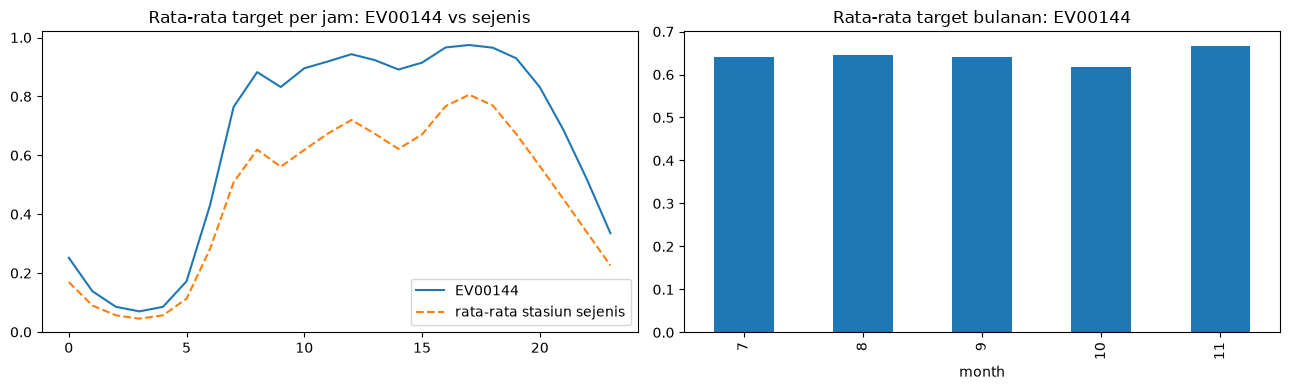


Rata-rata target EV00144: 0.6412
Rata-rata target stasiun sejenis: 0.4607


In [ ]:
target_station = "EV00144"
station_profile_check = train_full.loc[train_full["station_id"] == target_station,
                                       ["station_id", "location_type_code", "city_code", "charger_type_code",
                                        "power_output_kw", "ports_total", "latitude", "longitude"]].iloc[0]
print("Profil EV00144:")
print(station_profile_check)

same_loc_type = train_full.loc[train_full["location_type_code"] == station_profile_check["location_type_code"]]

hourly_target = train_full.loc[train_full["station_id"] == target_station].groupby("hour")[TARGET_COL].mean()
hourly_peer_avg = same_loc_type.loc[same_loc_type["station_id"] != target_station].groupby("hour")[TARGET_COL].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hourly_target.index, hourly_target.values, label="EV00144")
axes[0].plot(hourly_peer_avg.index, hourly_peer_avg.values, label="rata-rata stasiun sejenis", linestyle="--")
axes[0].set_title("Rata-rata target per jam: EV00144 vs sejenis")
axes[0].legend()

monthly_target = train_full.loc[train_full["station_id"] == target_station].groupby("month")[TARGET_COL].mean()
monthly_target.plot(kind="bar", ax=axes[1], title="Rata-rata target bulanan: EV00144")
plt.tight_layout()
plt.show()


print(f"\nRata-rata target EV00144: {train_full.loc[train_full['station_id']==target_station, TARGET_COL].mean():.4f}")
print(f"Rata-rata target stasiun sejenis: {same_loc_type.loc[same_loc_type['station_id']!=target_station, TARGET_COL].mean():.4f}")

#### Temuan: EV00144 Bukan Anomali Data

EV00144 punya ports_total=24 dengan nilai maksimum di seluruh dataset pada Highway Corridor dekat San Francisco (kota dengan rata-rata utilization tertinggi). Rata-rata target-nya 0,6412, jauh di atas stasiun sejenis (0,4607), konsisten lebih tinggi di hampir semua jam dan stabil di semua bulan (0,62-0,67) dan bukan lonjakan musiman yang aneh. Ini kombinasi atribut yang genuinely langka, bukan galat pencatatan, sehingga tidak perlu dikoreksi. Kombinasi bukti dari sel ini menegaskan: plateau RMSE yang ditemukan sejak Fase K bukan karena keterbatasan usaha, tapi karena sisa error memang mendekati batas noise struktural data.

### ****RINGKASAN MODELING****

**Perjalanan model**

| Tahap | Model | RMSE (CV) |
|---|---|---|
| Baseline terbaik | loc_hour_target_mean | 0,1429 |
| Model referensi | Linear Regression | 0,1356 |
| Model pohon pertama | Random Forest | 0,1284 (503 detik, tidak proporsional) |
| Model utama terpilih | LightGBM (tuning ringan) | 0,1013 |
| Setelah target encoding bertingkat dan smoothing | LightGBM | 0,0744 |
| Setelah CV diperbaiki (fold bersih) dan retuning | LightGBM | 0,0664 |
| Setelah model kedua (CatBoost) diblend | LightGBM + CatBoost | 0,0662 |
| Setelah model ketiga (XGBoost) diblend | 3 model | 0,0661 |
| Setelah stacking meta-learner | 3 model, bobot Ridge | 0,0658 (OOF) |
| Setelah pembobotan recency | 3 model, sample_weight | 0,0674 (fold5) |

**Progres submission Kaggle**

| Versi | Metode | RMSE Leaderboard |
|---|---|---|
| v1 | LightGBM tunggal, tuning ringan | 0,07315 |
| v2 | LightGBM + CatBoost, target encoding bertingkat | 0,06852 |
| v3 | 3 model (+XGBoost), CV diperbaiki, parameter ditata ulang | 0,06844 |
| v4 | Bobot blend dari stacking meta-learner | 0,06832 |
| **v5 (final)** | Ditambah pembobotan recency | **0,06827** |

**Fitur yang terbukti membantu**: target encoding bertingkat (station_id; location_type x hour; station_id x hour; station_id x hour x is_weekend, dengan shrinkage), pembobotan recency terhadap baris latih yang lebih baru.

**Fitur dan pendekatan yang dicoba tetapi ditolak** karena tidak memperbaiki atau justru memperburuk RMSE: (station_id, hour, day_of_week) yang terlalu tajam, city_hour_target_mean dan is_bad_weather yang redundan, kepadatan spasial antarstasiun, granularitas 30 menit, dan transformasi logit pada target.

**Temuan metodologis penting**: skema validasi silang awal (fold4, menyembunyikan seluruh November) ternyata bias pesimis karena kategori cuaca freezing sama sekali tidak ada di data latihnya. Setelah diganti dengan fold bersih (fold5, hanya menyembunyikan seminggu terakhir), skor CV menjadi jauh lebih representatif terhadap skor leaderboard sesungguhnya, dan sejumlah keputusan tuning sebelumnya (num_leaves, smoothing_k) berbalik arah. Analisis residual pada model final juga mengonfirmasi tidak ada bias sistematis tersisa di segmen manapun, sehingga plateau RMSE yang dicapai bersifat mendekati batas noise struktural data, bukan keterbatasan eksplorasi.

**Model final**: blend 3 model (LightGBM, CatBoost, XGBoost) dengan bobot hasil stacking meta-learner, dilatih pada seluruh data train dengan pembobotan recency (half_life=7 hari). Fitur, artefak model, dan file submission tersimpan di Dataset/Clean dan Dataset/Submission untuk keperluan reproduksi.

<div align="center">
  <img src="https://i.pinimg.com/1200x/fe/26/bf/fe26bfc0d4298cc52e853513eebb2ea9.jpg" alt="Hanaori Imutt" width="300">
  <h5>Lanjut ke "Evaluation" finally </h5>
</div>